In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%cd /content/drive/MyDrive/TDA/Data_processing/GPR/train_data/raw_data

/content/drive/MyDrive/TDA/Data_processing/GPR/train_data/raw_data


경로 탐색 코드

In [ ]:
import os

# 현재 디렉토리 경로를 가져옴
current_directory = os.getcwd()

# 현재 디렉토리에 있는 파일 목록을 가져옴
files_in_directory = os.listdir(current_directory)

# .jpg 확장자로 끝나는 파일만 필터링
jpg_files = [file for file in files_in_directory if file.lower().endswith('.jpg')]

print("현재 디렉토리 경로:", current_directory)
print("JPG 파일 목록:")
for file in jpg_files:
    my_image = Image.open(file)

현재 디렉토리 경로: /content/drive/MyDrive/TDA/Data_processing/GPR/train_data/raw_data
JPG 파일 목록:


# Json에서 이미지 읽기

/content/drive/MyDrive/TDA/dataset/labels/train_json/pipe_yz_MALA_000013.json
True
(256, 300, 3)
141 85 24 41


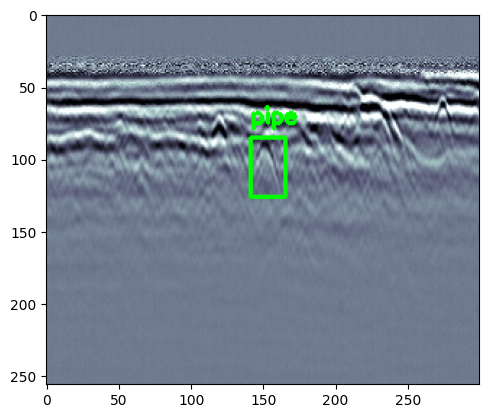

In [ ]:
import json
import os
import cv2
import matplotlib.pyplot as plt

def draw_bbox_from_json(img_path, json_dir):
    # 1. 이미지 읽기
    img = cv2.imread(img_path)
    filename = os.path.basename(img_path)
    json_path = os.path.join(json_dir, filename.replace('.jpg', '.json'))

    print(json_path)
    print(os.path.exists(json_path))
    if not os.path.exists(json_path):
        print("JSON 파일을 찾을 수 없습니다.")
        return img

    # 2. JSON 데이터 로드
    with open(json_path, 'r', encoding='utf-8') as f:
        data = json.load(f)

    # 3. Bbox 정보 추출
    anno = data['annotation']
    x = int(anno['bbox_x'])
    y = int(anno['bbox_y'])
    w = int(anno['bbox_w'])
    h = int(anno['bbox_h'])
    print(img.shape)
    # 원본 이미지 크기 (JSON 기준) 대비 현재 이미지 비율 계산 (크기 무시 방지)
    orig_w = int(anno['bbox_xM'])
    orig_h = int(anno['bbox_yM'])
    curr_h, curr_w = img.shape[:2]

    # 크기가 다르다면 좌표 스케일링
    scale_x = curr_w / orig_w
    scale_y = curr_h / orig_h

    nx, ny = int(x * scale_x), int(y * scale_y)
    nw, nh = int(w * scale_x), int(h * scale_y)
    print(nx, ny, nw, nh)
    # 4. 이미지에 그리기 (초록색 상자)
    cv2.rectangle(img, (nx, ny), (nx + nw, ny + nh), (0, 255, 0), 2)
    cv2.putText(img, data['targetType'], (nx, ny - 10),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    return img

# 사용 예시
processed_img_with_box = draw_bbox_from_json('/content/drive/MyDrive/TDA/dataset/images/train/pipe_yz_MALA_000013.jpg', '/content/drive/MyDrive/TDA/dataset/labels/train_json')
plt.imshow(cv2.cvtColor(processed_img_with_box, cv2.COLOR_BGR2RGB))

False

# 신호 감쇠처리

1. 시간 이득 보정

이미지의 아래쪽으로 갈수록(Y값이 커질수록) 픽셀 값에 가중치를 곱해 어두워진 부분을 강제로 밝게 만듭니다.

2. 열 단위(Trace-by-trace) FFT 및 보정

- 이미지의 각 열을 하나의 신호로 취급하여 주파수 영역으로 보냅니다.
- 이때 논문의 핵심 원칙인 "위상은 유지하고 진폭만 수정한다"는 점

3. 스펙트럼 균형 (Spectral Balancing)

감쇠로 인해 뭉툭해진 신호의 주파수 대역을 다시 넓혀주어(Whitening), 이미지의 해상도를 높입니다.

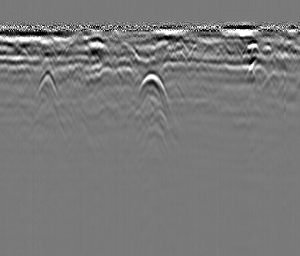

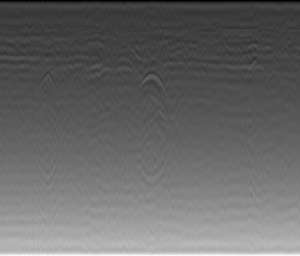

In [ ]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow # Import cv2_imshow for Colab

def process_gpr_image(image_path, beta=0.005, boost_factor=2.0):
    # 1. 이미지 로드 (흑백 모드)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
    rows, cols = img.shape

    # 결과 저장용 빈 행렬
    enhanced_img = np.zeros_like(img)

    # 2. 열 단위로 처리 (Trace-by-trace)
    for c in range(cols):
        trace = img[:, c]

        # --- (A) SEC Gain 적용 ---
        t = np.arange(rows)
        gain = (t + 1) * np.exp(beta * t)
        trace_gained = trace * gain

        # --- (B) FFT 및 Spectral Balancing ---
        # 1D FFT 수행
        fft_val = np.fft.fft(trace_gained)
        amplitude = np.abs(fft_val)
        phase = np.angle(fft_val) # 위상 보존 [cite: 524]

        # 진폭 보정: 고주파 성분(중간 주파수 대역)을 강화
        # 여기서는 단순화를 위해 전체 진폭을 일정 비율로 조정
        # 실제로는 논문의 Spectral Balancing 알고리즘 적용 가능
        avg_amp = np.mean(amplitude)
        amplitude[amplitude < avg_amp] *= boost_factor

        # --- (C) 역 FFT로 복원 ---
        new_fft = amplitude * np.exp(1j * phase)
        restored_trace = np.real(np.fft.ifft(new_fft))

        enhanced_img[:, c] = restored_trace

    # 3. 결과 정규화 (0~255 범위로 재조정)
    enhanced_img = cv2.normalize(enhanced_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return enhanced_img

# 실행 예시
image_path = './test_source_yz/pipe_yz_MALA_000049.jpg'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
cv2_imshow(img)
result = process_gpr_image('./test_source_yz/pipe_yz_MALA_000049.jpg')
cv2_imshow(result)

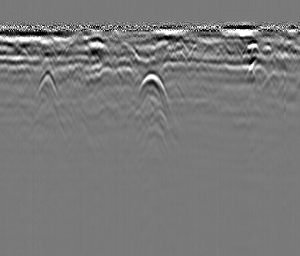

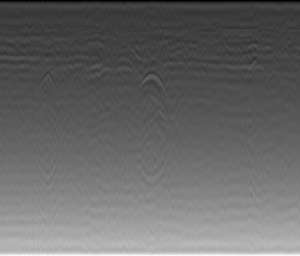

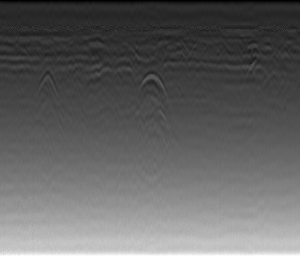

In [ ]:
import numpy as np
import cv2

def refined_gpr_process(image_path, beta=0.005, offset=10):
    # 1. 이미지 로드 및 크기 확인
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
    rows, cols = img.shape

    processed_img = np.zeros_like(img)

    # 2. 열 단위(Trace) 처리
    for c in range(cols):
        trace = img[:, c]

        # --- (A) SEC Gain 수정: 상단부 어두워짐 방지 ---
        t = np.arange(rows)
        # t 대신 (t + offset)을 사용하여 맨 윗부분이 0이 되지 않게 함
        gain = (t + offset) * np.exp(beta * t)
        trace_gained = trace * gain

        # --- (B) rfft 사용: 데칼코마니 현상 방지 ---
        # 실수 전용 FFT로 변환 (반사 방지의 핵심)
        f_coeff = np.fft.rfft(trace_gained)
        amplitude = np.abs(f_coeff)
        phase = np.angle(f_coeff) # 위상은 변하지 않아야 함 [cite: 19, 525]

        # --- (C) Spectral Balancing (단순화된 버전) ---
        # 주파수별로 선택적 이득 적용 [cite: 514]
        mean_amp = np.mean(amplitude)
        amplitude[amplitude < mean_amp] *= 1.5

        # --- (D) irfft로 복원 ---
        new_f_coeff = amplitude * np.exp(1j * phase)
        # irfft는 원본 행수(rows)를 명시해주는 것이 안전함
        restored_trace = np.fft.irfft(new_f_coeff, n=rows)

        processed_img[:, c] = restored_trace

    # 3. 결과 정규화 및 출력
    final_img = cv2.normalize(processed_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    return final_img

image_path = './test_source_yz/pipe_yz_MALA_000049.jpg'
img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
cv2_imshow(img)
result = process_gpr_image('./test_source_yz/pipe_yz_MALA_000049.jpg')
cv2_imshow(result)
result = refined_gpr_process('./test_source_yz/pipe_yz_MALA_000049.jpg')
cv2_imshow(result)

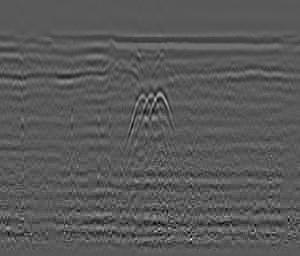

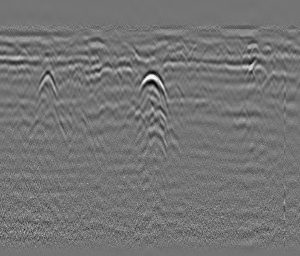

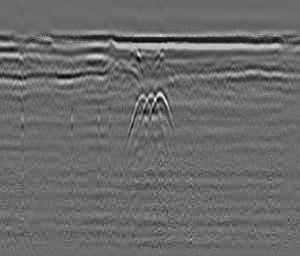

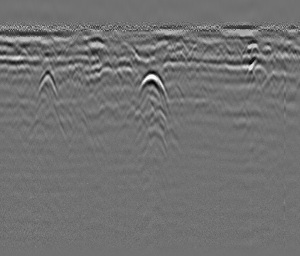

In [ ]:
import numpy as np
import cv2

def final_gpr_restoration(image_path, beta=0.003, offset=15):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
    rows, cols = img.shape
    processed_img = np.zeros_like(img)

    for c in range(cols):
        trace = img[:, c]

        # 1. DEWOW: 신호의 중심을 0으로 맞춤
        trace = trace - np.mean(trace)

        # 2. SEC Gain 적용 [cite: 324]
        t = np.arange(rows)
        gain = (t + offset) * np.exp(beta * t)
        trace_gained = trace * gain

        # 3. Tapering: 하단 끝부분을 부드럽게 (잔상 방지 핵심)
        taper_len = int(rows * 0.1)
        taper = np.ones(rows)
        taper[-taper_len:] = np.cos(np.linspace(0, np.pi/2, taper_len))
        trace_gained *= taper

        # 4. Zero-Padding 후 rfft (해상도 및 안정성 향상)
        n_fft = rows * 2
        f_coeff = np.fft.rfft(trace_gained, n=n_fft)
        amplitude = np.abs(f_coeff)
        phase = np.angle(f_coeff)

        # 5. Spectral Balancing: 특정 대역 선택적 강화 [cite: 514]
        # 저주파 노이즈는 억제하고 고주파(신호)는 유지
        freqs = np.fft.rfftfreq(n_fft)
        balancing_filter = np.where(freqs > 0.05, 1.2, 0.5)
        amplitude *= balancing_filter

        # 6. 복원 및 자르기
        restored = np.fft.irfft(amplitude * np.exp(1j * phase), n=n_fft)
        processed_img[:, c] = restored[:rows] # 원래 크기로 복구
    return cv2.normalize(processed_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

result = final_gpr_restoration('/content/drive/MyDrive/TDA/dataset/images/train_signal/pipe_yz_MALA_000038.jpg')
cv2_imshow(result)
result = final_gpr_restoration('/content/drive/MyDrive/TDA/dataset/images/train_signal/pipe_yz_MALA_000049.jpg')
cv2_imshow(result)
result = final_gpr_restoration('/content/drive/MyDrive/TDA/dataset/images/train/pipe_yz_MALA_000038.jpg')
cv2_imshow(result)
result = final_gpr_restoration('/content/drive/MyDrive/TDA/dataset/images/train/pipe_yz_MALA_000049.jpg')
cv2_imshow(result)

# overlay gpr image with bbox

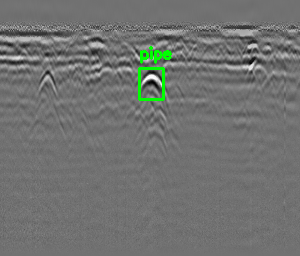

In [ ]:
import numpy as np
import cv2
import json
import os

def process_gpr_with_bbox(img_path, json_path, beta=0.003, offset=15):
    # 1. 이미지 로드 및 기초 처리
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
    rows, cols = img.shape
    processed_data = np.zeros_like(img)

    # 2. 열 단위(Trace) 감쇠 복원 수행
    for c in range(cols):
        trace = img[:, c]
        trace = trace - np.mean(trace) # DEWOW

        # SEC Gain [cite: 324]
        t = np.arange(rows)
        gain = (t + offset) * np.exp(beta * t)
        trace_gained = trace * gain

        # Tapering (잔상 방지)
        taper_len = int(rows * 0.1)
        taper = np.ones(rows)
        taper[-taper_len:] = np.cos(np.linspace(0, np.pi/2, taper_len))
        trace_gained *= taper

        # rfft & Spectral Balancing [cite: 325]
        n_fft = rows * 2 # Zero-padding
        f_coeff = np.fft.rfft(trace_gained, n=n_fft)
        amplitude = np.abs(f_coeff)
        phase = np.angle(f_coeff) # 위상 보존 [cite: 195]

        # 고주파 강화 필터
        freqs = np.fft.rfftfreq(n_fft)
        amplitude *= np.where(freqs > 0.05, 1.3, 0.7)

        # 복원
        restored = np.fft.irfft(amplitude * np.exp(1j * phase), n=n_fft)
        processed_data[:, c] = restored[:rows]

    # 3. 밝기 범위 재조정 (0 ~ 255)
    final_img = cv2.normalize(processed_data, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # 시각화를 위해 컬러 이미지로 변환
    display_img = cv2.cvtColor(final_img, cv2.COLOR_GRAY2BGR)

    # 4. JSON에서 Bbox 정보 가져와서 그리기
    if os.path.exists(json_path):
        with open(json_path, 'r', encoding='utf-8') as f:
            label_data = json.load(f)

        anno = label_data['annotation']
        x, y = int(anno['bbox_x']), int(anno['bbox_y'])
        w, h = int(anno['bbox_w']), int(anno['bbox_h'])

        # Bbox 그리기 (초록색 상자)
        cv2.rectangle(display_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(display_img, label_data['targetType'], (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    return display_img

# 사용 예시
result = process_gpr_with_bbox('/content/drive/MyDrive/TDA/dataset/images/train/pipe_yz_MALA_000049.jpg', '/content/drive/MyDrive/TDA/dataset/labels/train_json/pipe_yz_MALA_000049.json')
cv2_imshow(result)

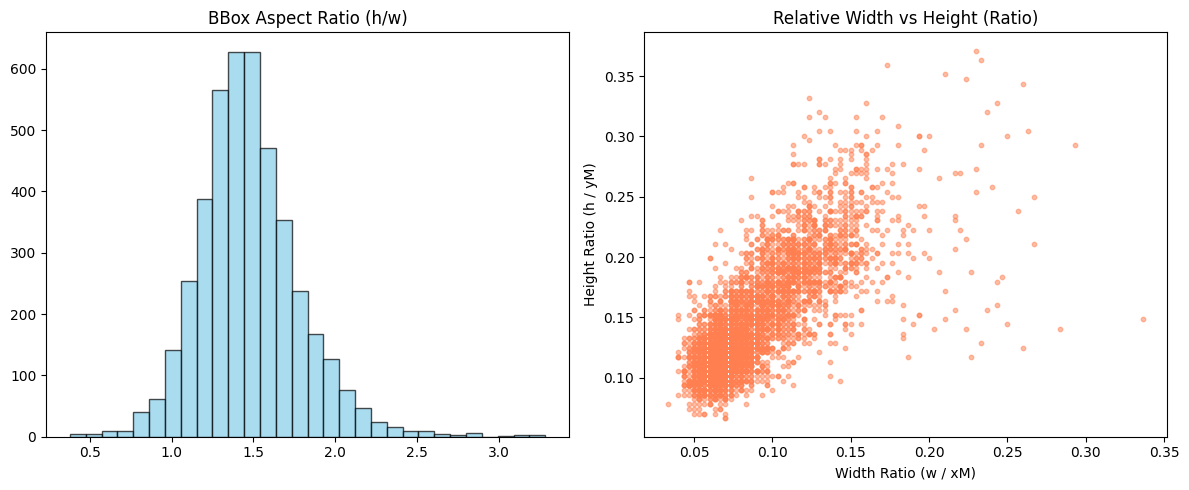

총 분석 파일 수: 4294
평균 면적 비율: 0.014040
최대 면적 비율: 0.089375 (pipe_yz_MALA_042030.json)
최소 면적 비율: 0.002604 (pipe_yz_MALA_035245.json)
이미지 대비 평균 점유율: 1.40%
0.07333333333333333


In [ ]:
import json
import os
import matplotlib.pyplot as plt
import numpy as np

def plot_json_bbox_distribution_relative(json_dir):
    widths_ratio = []
    heights_ratio = []
    areas_ratio = []
    gradients = [] # 기울기(h/w)는 비율로 계산해도 동일함

    max_area_ratio = 0
    min_area_ratio = 1.0
    min_file = ""
    max_file = ""

    file_list = [f for f in os.listdir(json_dir) if f.endswith('.json')]

    if not file_list:
        print("JSON 파일을 찾을 수 없습니다.")
        return

    for filename in file_list:
        json_path = os.path.join(json_dir, filename)

        try:
            with open(json_path, 'r', encoding='utf-8') as f:
                label_data = json.load(f)

            anno = label_data['annotation']
            # 원본 이미지 크기 추출
            orig_W = int(anno['bbox_xM'])
            orig_H = int(anno['bbox_yM'])

            # 현재 Bbox 크기
            w = int(anno['bbox_w'])
            h = int(anno['bbox_h'])

            # [핵심] 이미지 크기 대비 비율 계산 (0.0 ~ 1.0)
            w_ratio = w / orig_W
            h_ratio = h / orig_H
            area_ratio = w_ratio * h_ratio

            widths_ratio.append(w_ratio)
            heights_ratio.append(h_ratio)
            areas_ratio.append(area_ratio)
            gradients.append(h / w) # 종횡비는 절대값/비율값 결과가 같음

            # 통계 업데이트
            if max_area_ratio < area_ratio:
                max_area_ratio = area_ratio
                max_file = filename
            if min_area_ratio > area_ratio:
                min_area_ratio = area_ratio
                min_file = filename

        except Exception as e:
            print(f"파일 읽기 오류 ({filename}): {e}")

    # 시각화
    plt.figure(figsize=(12, 5))

    # 왼쪽: 종횡비 분포
    plt.subplot(1, 2, 1)
    plt.hist(gradients, bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    plt.title('BBox Aspect Ratio (h/w)')

    # 오른쪽: 너비 비율 vs 높이 비율 산점도
    plt.subplot(1, 2, 2)
    plt.scatter(widths_ratio, heights_ratio, alpha=0.5, c='coral', s=10)
    plt.title('Relative Width vs Height (Ratio)')
    plt.xlabel('Width Ratio (w / xM)')
    plt.ylabel('Height Ratio (h / yM)')

    plt.tight_layout()
    plt.show()

    if areas_ratio:
        print(f"총 분석 파일 수: {len(areas_ratio)}")
        print(f"평균 면적 비율: {np.mean(areas_ratio):.6f}")
        print(f"최대 면적 비율: {max_area_ratio:.6f} ({max_file})")
        print(f"최소 면적 비율: {min_area_ratio:.6f} ({min_file})")
        # 면적 비율을 %로 환산해서 보고 싶다면 결과에 * 100
        print(f"이미지 대비 평균 점유율: {np.mean(areas_ratio)*100:.2f}%")

        print( widths_ratio[-1])

# 사용 예시
plot_json_bbox_distribution_relative('/content/drive/MyDrive/TDA/dataset/labels/val_json/')


## 신호 감쇠 +

| 순서|추가여부 | 방법론| 핵심 코드| 출처| 목적|
|:---:|:---:|:---:|:---:|:---:|:---:|
|1|Y|배경 제거 (Background Removal)|img - np.mean(img, axis=1)|Paper 2: (Subtracting average)|Gain 적용 전 수평 노이즈(Ringing)를 제거하여 잡음 증폭 방지|
|2|N|DEWOW|trace - np.mean(trace)|기존 코드: 일반 GPR 처리 (Standard practice)|신호의 저주파 편향(DC Offset)을 제거하여 베이스라인 0점 조정|
|3|N|SEC Gain|(t + offset) * exp(beta * t)Paper 3: (Attenuation Correction)|깊이에 따른 기하학적 확산 및 매질 흡수 에너지 손실 물리적 보정|
|4|N|테이퍼링 (Tapering)|trace * cos_window|기존 코드: 창 함수 (Windowing)|데이터 하단 끝부분을 부드럽게 감쇄시켜 FFT 시 잔상(Artifact) 억제|
|5|N|스펙트럼 밸런싱 (Spectral Balancing)|amplitude * balancing_filter|Paper 3: (Amplitude balancing)|특정 주파수 대역(파이프 반사파)을 선택적으로 강화하여 해상도 증대|
|6|Y|공간 필터링 (Spatial Filtering)|cv2.medianBlur(img, 3)|Paper 1:  (Suppression of random noise)|복원 후 남은 점 노이즈를 제거하되 파이프의 쌍곡선 엣지는 보존|
|7|Y|적응형 대비 조정 (CLAHE)|clahe.apply(norm_img)|Paper 1:  (Contrast adjustment)|지역적 대비를 최적화하여 묻혀있던 파이프의 기하학적 위상 강조|

제시해주신 Bbox의 크기($21 \times 32$)와 전체 이미지 크기($300 \times 256$)를 분석했을 때, CLAHE의 tileGridSize를 결정하는 논리적인 가이드를 논문 근거와 함께 설명해 드립니다.결론부터 말씀드리면, 사용자의 데이터에는 (8, 8) 혹은 (4, 4)가 가장 적합합니다. 그 이유를 수치적으로 풀이해 보겠습니다.1. CLAHE 타일 크기와 타겟(Bbox)의 상관관계 분석CLAHE는 이미지를 격자(Tile)로 나누어 각 영역 내에서 대비를 최적화합니다. 이때 "타일 하나가 타겟(파이프 쌍곡선 정점)을 충분히 포함하면서도 주변 배경과의 차이를 인지할 수 있는 크기"여야 위상 추출이 명확해집니다.이미지 크기: $300 \times 256$Bbox 크기: $21 \times 32$ (타겟 영역)시나리오 A: tileGridSize=(8, 8) 일 때 (추천)타일 한 칸의 크기: $(300/8) \times (256/8) \approx \mathbf{37 \times 32}$ 픽셀분석: 타일 크기($37 \times 32$)가 Bbox 크기($21 \times 32$)보다 약간 더 큽니다.효과: 타겟인 파이프가 타일 안에 쏙 들어가면서 주변 연약지반(배경)과의 대비를 계산하기에 가장 이상적인 비율입니다. 논문 1에서 강조하는 "국부적 특징 추출(Localized feature extraction)"에 가장 부합하는 설정입니다.시나리오 B: tileGridSize=(16, 16) 일 때타일 한 칸의 크기: $(300/16) \times (256/16) \approx \mathbf{18 \times 16}$ 픽셀분석: 타일 크기가 Bbox보다 작아집니다.효과: 파이프 하나가 여러 타일에 걸치게 되어, 파이프 내부의 미세한 노이즈를 신호로 오인해 증폭시킬 위험이 큽니다. 위상수학적으로 '도형'을 가져오려 할 때 형태가 파편화될 수 있습니다.시나리오 C: tileGridSize=(4, 4) 일 때타일 한 칸의 크기: $(300/4) \times (256/4) = \mathbf{75 \times 64}$ 픽셀분석: 타일 크기가 타겟보다 2~3배 이상 큽니다.효과: 대비 보정 효과가 완만해집니다. 하단 노이즈가 심한 경우, 타일이 커질수록 노이즈 억제력은 좋아지지만 깊은 곳의 희미한 파이프 신호를 살리는 힘은 약해집니다.

In [ ]:
import cv2
import numpy as np

def gpr_final_preprocessing(image_path, beta=0.003, offset=15):
    """
    GPR 이미지에서 파이프의 위상수학적 특징(쌍곡선)을 추출하기 위한 최종 전처리 함수
    """
    # 1. 이미지 로드 (Gray Scale)
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
    rows, cols = img.shape

    # 2. 배경 제거 (Background Removal / Subtracting Average)
    # [출처: Paper 2 - Step 5] 수평 노이즈 선제거로 SEC Gain 시 잡음 증폭 방지
    avg_trace = np.mean(img, axis=1, keepdims=True)
    img_bg_removed = img - avg_trace

    processed_img = np.zeros_like(img)

    # 트레이스별 처리 루프
    for c in range(cols):
        trace = img_bg_removed[:, c]

        # 3. DEWOW: 신호의 중심축을 0으로 맞춤
        trace = trace - np.mean(trace)

        # 4. SEC Gain 적용 [출처: Paper 3 - Eq. 5]
        # 거리(t)에 따른 기하학적 확산 및 매질 감쇠 보상
        t = np.arange(rows)
        gain = (t + offset) * np.exp(beta * t)
        trace_gained = trace * gain

        # 5. Tapering: FFT 연산 시 하단 경계면 잔상(Artifact) 방지
        taper_len = int(rows * 0.1)
        taper = np.ones(rows)
        taper[-taper_len:] = np.cos(np.linspace(0, np.pi/2, taper_len))
        trace_gained *= taper

        # 6. Spectral Balancing (FFT 기반 주파수 강화) [출처: Paper 3 - Eq. 7]
        n_fft = rows * 2
        f_coeff = np.fft.rfft(trace_gained, n=n_fft)
        freqs = np.fft.rfftfreq(n_fft)

        # 저주파 노이즈 억제 및 타겟 주파수 대역 유지 (0.05 문턱값 적용)
        balancing_filter = np.where(freqs > 0.05, 1.2, 0.5)
        restored = np.fft.irfft(f_coeff * balancing_filter, n=n_fft)
        processed_img[:, c] = restored[:rows]

    # 7. 공간 필터링 (Spatial Filtering) [출처: Paper 1 - Section 109]
    # Median Blur는 엣지(쌍곡선 외곽선)를 보존하면서 무작위 점 노이즈를 제거함
    denoised_img = cv2.medianBlur(processed_img.astype(np.float32), 3)

    # 8. CLAHE (적응형 히스토그램 평활화) [출처: Paper 1 - Section 144]
    # Bbox(21x32) 크기에 맞춰 타일 크기를 (8, 8)로 설정하여 국부 대비 극대화
    norm_img = cv2.normalize(denoised_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    # clipLimit=2.0 (대비 한계), tileGridSize=(8, 8) (타일당 약 37x32 픽셀)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    final_output = clahe.apply(norm_img)

    return final_output

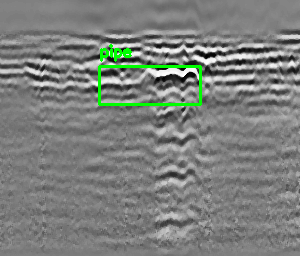

In [ ]:
import numpy as np
import cv2
import json
import os

def process_gpr_with_bbox(f,img_path, json_path, beta=0.003, offset=15):

    final_img = f(img_path)

    # 시각화를 위해 컬러 이미지로 변환
    display_img = cv2.cvtColor(final_img, cv2.COLOR_GRAY2BGR)

    # 4. JSON에서 Bbox 정보 가져와서 그리기
    if os.path.exists(json_path):
        with open(json_path, 'r', encoding='utf-8') as f:
            label_data = json.load(f)

        anno = label_data['annotation']
        x, y = int(anno['bbox_x']), int(anno['bbox_y'])
        w, h = int(anno['bbox_w']), int(anno['bbox_h'])

        # Bbox 그리기 (초록색 상자)
        cv2.rectangle(display_img, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(display_img, label_data['targetType'], (x, y - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 255, 0), 2)

    return display_img

# 사용 예시
result = process_gpr_with_bbox(gpr_final_preprocessing,'/content/drive/MyDrive/TDA/dataset/images/val/pipe_yz_MALA_000873.jpg', '/content/drive/MyDrive/TDA/dataset/labels/val_json/pipe_yz_MALA_000873.json')
cv2_imshow(result)

## 신호 감쇠 +

| 순서|추가여부 | 방법론| 핵심 코드| 출처| 목적|
|:---:|:---:|:---:|:---:|:---:|:---:|
|1|Y|배경 제거 (Background Removal)|img - np.mean(img, axis=1)|Paper 2: (Subtracting average)|Gain 적용 전 수평 노이즈(Ringing)를 제거하여 잡음 증폭 방지|
|2|N|DEWOW|trace - np.mean(trace)|기존 코드: 일반 GPR 처리 (Standard practice)|신호의 저주파 편향(DC Offset)을 제거하여 베이스라인 0점 조정|
|3|N|SEC Gain|(t + offset) * exp(beta * t)Paper 3: (Attenuation Correction)|깊이에 따른 기하학적 확산 및 매질 흡수 에너지 손실 물리적 보정|
|4|N|테이퍼링 (Tapering)|trace * cos_window|기존 코드: 창 함수 (Windowing)|데이터 하단 끝부분을 부드럽게 감쇄시켜 FFT 시 잔상(Artifact) 억제|
|5|N|스펙트럼 밸런싱 (Spectral Balancing)|amplitude * balancing_filter|Paper 3: (Amplitude balancing)|특정 주파수 대역(파이프 반사파)을 선택적으로 강화하여 해상도 증대|
|6|Y|바이래터 필터링 (Spatial Filtering)|d=9, sigma=75|Paper 1:  (Suppression of random noise)|[향상] 엣지(쌍곡선)는 유지하고 노이즈만 스무딩|
|7|Y|적응형 대비 조정 (CLAHE)|clahe.apply(norm_img)|Paper 1:  (Contrast adjustment)|지역적 대비를 최적화하여 묻혀있던 파이프의 기하학적 위상 강조|
|8|Y|형태학적 열기|MORPH_OPEN (3x3)|Gemini 제|미세 노이즈 파편 제거로 위상 구조 단순화|

In [ ]:
import cv2
import numpy as np

def gpr_v2_5_topology_optimized(image_path, beta=0.003, offset=15):
    # 1. 이미지 로드 및 배경 제거
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE).astype(np.float32)
    # SEC 적용 전 수평 노이즈 제거
    img = img - np.mean(img, axis=1, keepdims=True)

    rows, cols = img.shape
    processed_img = np.zeros_like(img)

    # 트레이스별 처리 (물리적 보정 단계)
    for c in range(cols):
        trace = img[:, c]
        trace = trace - np.mean(trace) # 2. DEWOW

        # 3. SEC Gain & 4. Tapering
        t = np.arange(rows)
        gain = (t + offset) * np.exp(beta * t)
        trace_gained = trace * gain

        taper_len = int(rows * 0.1)
        taper = np.ones(rows)
        taper[-taper_len:] = np.cos(np.linspace(0, np.pi/2, taper_len))
        trace_gained *= taper

        # 5. Spectral Balancing (FFT)
        n_fft = rows * 2
        f_coeff = np.fft.rfft(trace_gained, n=n_fft)
        freqs = np.fft.rfftfreq(n_fft)
        balancing_filter = np.where(freqs > 0.05, 1.2, 0.5)

        restored = np.fft.irfft(f_coeff * balancing_filter, n=n_fft)
        processed_img[:, c] = restored[:rows]

    # [업그레이드] 6. Bilateral Filter: 엣지 보존 노이즈 제거
    # 미디언 필터보다 쌍곡선의 곡률을 훨씬 더 잘 유지합니다.
    denoised = cv2.bilateralFilter(processed_img.astype(np.float32), 9, 75, 75)

    # [최적화] 7. CLAHE: 타겟 크기(1/9)에 맞춘 격자 설정
    norm_img = cv2.normalize(denoised, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_img = clahe.apply(norm_img)

    # [신규] 8. Morphological Opening: 위상 파편 제거
    # 위상수학 알고리즘이 작은 점들을 객체로 오인하지 않도록 기하학적 구조를 단순화합니다.
    kernel = np.ones((2, 2), np.uint8)
    final_v2_5 = cv2.morphologyEx(clahe_img, cv2.MORPH_OPEN, kernel)

    return final_v2_5 #clahe_img #

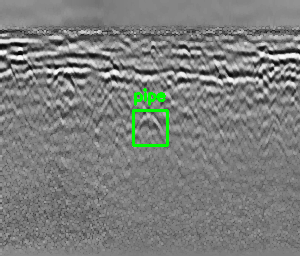

In [ ]:
# 사용 예시
result = process_gpr_with_bbox(gpr_v2_5_topology_optimized,'/content/drive/MyDrive/TDA/dataset/images/train/pipe_yz_MALA_000064.jpg', '/content/drive/MyDrive/TDA/dataset/labels/train_json//pipe_yz_MALA_000064.json')
cv2_imshow(result)

In [ ]:
# 사용 예시
result = process_gpr_with_bbox(gpr_v2_5_topology_optimized,'/content/drive/MyDrive/TDA/dataset/images/train/pipe_yz_MALA_000013.jpg', '/content/drive/MyDrive/TDA/dataset/labels/train_json//pipe_yz_MALA_000013.json')
cv2_imshow(result)

error: OpenCV(4.13.0) :-1: error: (-5:Bad argument) in function 'imread'
> Overload resolution failed:
>  - Expected 'filename' to be a str or path-like object
>  - Expected 'filename' to be a str or path-like object
>  - Expected 'filename' to be a str or path-like object




## 신호 감쇄 + 저장


### 저장 경로

- train: src
- train_signal: final_gpr_restoration
- train_signal_v1: gpr_final_preprocessing


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

input_dir_tr = '/content/drive/MyDrive/TDA/dataset/images/train'
input_dir_val = '/content/drive/MyDrive/TDA/dataset/images/val'
output_dir_val = '/content/drive/MyDrive/TDA/dataset/images/val_signal_v2'
output_dir_tr = '/content/drive/MyDrive/TDA/dataset/images/train_signal_v2'

# 2. 폴더 매핑 (입력 폴더와 그에 대응하는 출력 폴더 쌍)
dirs_to_process = [
    (input_dir_tr, output_dir_tr),
    (input_dir_val, output_dir_val)
]

# 결과 디렉토리가 없으면 생성
if not os.path.exists(output_dir_tr):
    os.makedirs(output_dir_tr)
    print(f"디렉토리 생성됨: {output_dir_tr}")
if not os.path.exists(output_dir_val):
    os.makedirs(output_dir_val)
    print(f"디렉토리 생성됨: {output_dir_val}")



for in_dir, out_dir in dirs_to_process:
  count = 0
  # 이미지 파일 목록 가져오기
  files = [f for f in os.listdir(in_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
  print(f"\n[{in_dir}]에서 [{out_dir}]로 변환 시작 (총 {len(files)}개)")



  for count, filename in enumerate(tqdm(files)):
    # 1. 이미지 읽기
    img_path = os.path.join(in_dir, filename)
    img = cv2.imread(img_path)

    if img is None:
        continue

    # 2. 신호 감쇄 적용
    # attenuation_factor는 데이터의 특성에 맞춰 조절하세요 (0.001 ~ 0.01 사이 권장)

    # -------------
    # 디렉토리 경로
    # -------------
    # src_signal: final_gpr_restoration
    # src_signal_v1: gpr_final_preprocessing
    # src_signal_v2: gpr_v2_5_topology_optimized

    processed_img = gpr_v2_5_topology_optimized(img_path)

    #if count < 5:
    #    print(f"Sample {count+1}: {filename}")
    #    cv2_imshow(img)
    #    cv2_imshow(processed_img)

    # 3. 동일한 이름으로 저장
    save_path = os.path.join(out_dir, filename)
    cv2.imwrite(save_path, processed_img)

print("\n모든 작업이 완료되었습니다.")

디렉토리 생성됨: /content/drive/MyDrive/TDA/dataset/images/train_signal_v2
디렉토리 생성됨: /content/drive/MyDrive/TDA/dataset/images/val_signal_v2

[/content/drive/MyDrive/TDA/dataset/images/train]에서 [/content/drive/MyDrive/TDA/dataset/images/train_signal_v2]로 변환 시작 (총 2997개)


100%|██████████| 2997/2997 [03:13<00:00, 15.47it/s]



[/content/drive/MyDrive/TDA/dataset/images/val]에서 [/content/drive/MyDrive/TDA/dataset/images/val_signal_v2]로 변환 시작 (총 4294개)


100%|██████████| 4294/4294 [04:41<00:00, 15.27it/s]


모든 작업이 완료되었습니다.


# Persistent homology 구하기

## Remake 5/5

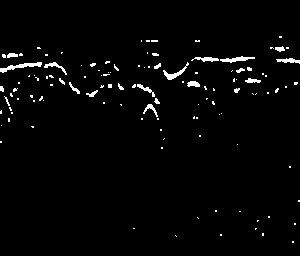

connected label [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]] 
 stats[[    0     0   300   256 75040]
 [  279    36     3     2     6]
 [  141    40     1     2     2]
 [  146    40     4     2     8]
 [  151    40     7     2    14]
 [  195    40     5     2     9]
 [   37    47     4     2     7]
 [  270    47     4     2     6]
 [  275    46    10     6    39]
 [  286    47     3     2     6]
 [    7    53    11     5    41]
 [   19    53     4     3    10]
 [   61    52     2     2     3]
 [  147    52     1     2     2]
 [  152    53     7     3    18]
 [    2    54     4     4    14]
 [   45    54     3     2     6]
 [  191    57    28     5    84]
 [  220    56    35     7   117]
 [  276    58    24     6    82]
 [  105    61     5     3    11]
 [    0    62    42    11   162]
 [   44    62    23    13    77]
 [   90    63     6     4    17]
 [  154    63     7     6    26]
 [  163    62    26    18   116]

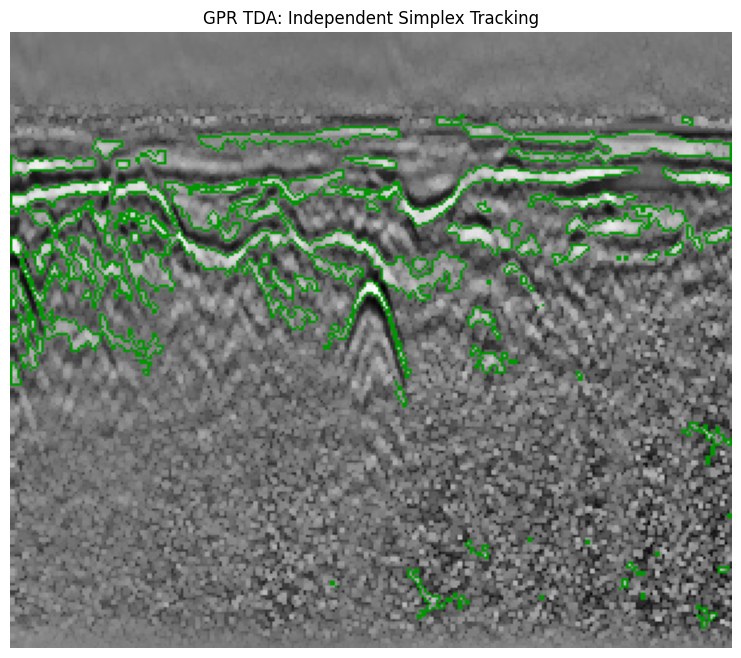

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow # 코랩 전용 이미지 출력 함수 임포트

def analyze_gpr_tda_v1(image_path, num_seeds=200, start_threshold=190, step=2):
    # 1. 이미지 로드 및 전처리
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return print("이미지를 찾을 수 없습니다.")

    # 애매한 부분
    #cv2_imshow(img)
    # 가우시안 블러로 미세 노이즈 제거 (GPR 특성상 노이즈가 많음)
    #img_blur = cv2.GaussianBlur(img, (5, 5), 0)
    # cv2_imshow(img_blur)
    # 해당 부분에 대해서 좀 봐야 할 거 같습니다.

    # 2. 초기 High-level Seed 생성 (가장 밝은 영역 7~10개 추출)
    # _: 적용된 임계값
    # mask: 0과 255로 이루어진 2D 이진 행렬
    _, initial_mask = cv2.threshold(img, start_threshold, 255, cv2.THRESH_BINARY)
    cv2_imshow(initial_mask)

    # input: initial_mask: 특정 임계값 t에서의 이진 행렬
    # return:
    #     - num_labels:(정수) 배경을 포함한 총 연결 성분의 개수
    #     - labels:(2D 행렬) 각 픽셀이 어떤 객체에 속하는지 번호가 매겨진 맵
    #     - stats: (2D 배열) 각 객체의 바운딩 박스 및 면적
    #     - centroids: (2D배열) 각 객체의 무게중심 좌표
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(initial_mask)
    print(f"connected label {labels} \n stats{stats}")

    # 면적 순으로 정렬하여 상위 n개만 넘버링 (배경 제외)
    sorted_idx = np.argsort(stats[1:, cv2.CC_STAT_AREA])[::-1][:num_seeds]
    seeds = {i+1: {'label': i+1, 'last_area': stats[idx+1, cv2.CC_STAT_AREA],
                   'is_frozen': False, 'final_mask': None} for i, idx in enumerate(sorted_idx)}

    # 초기 레이블 재설정
    current_labels = np.zeros_like(labels)
    for i, idx in enumerate(sorted_idx):
        current_labels[labels == idx+1] = i+1

    # 3. Filtration 진행 (임계값을 낮추며 확장)
    for t in range(start_threshold - step, 120, -step):
        _, current_mask = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)
        #cv2_imshow(current_mask)

        # temp_labels, _, temp_stats, _ = cv2.connectedComponentsWithStats(current_mask)
        # 5개의 인자를 정확히 받아옵니다 (retval, labels, stats, centroids)
        num_objects, labels_map, temp_stats, _ = cv2.connectedComponentsWithStats(current_mask)


        # 각 씨앗별로 확장성 검사
        for s_id, info in seeds.items():
            if info['is_frozen']: continue

            # 현재 객체 영역 픽셀 위치 추출
            y, x = np.where(current_labels == s_id)
            if len(y) == 0: continue

            # 현재 임계값 t에서 이 객체가 속한 새로운 영역의 크기 확인
            # (씨앗의 중심점 위치가 포함된 새로운 레이블 탐색)
            target_row, target_col = int(y[0]), int(x[0])
            new_label_at_seed = labels_map[target_row, target_col]
            if new_label_at_seed == 0: continue

            new_area = temp_stats[new_label_at_seed, cv2.CC_STAT_AREA]

            # 4. 급격한 변화 포착 (Area Explosion Detection)
            # 이전 면적 대비 증가율이 일정 수준(예: 1.5배) 이상이면 확장을 멈춤(박제)

            if ((new_area > info['last_area'] *2)): #3: > 5:  # 1.8은 GPR 특성에 따라 조정 가능
                info['is_frozen'] = True
                info['final_mask'] = (current_labels == s_id).astype(np.uint8) * 255
            else:
                # 면적이 완만하게 증가하면 레이블 업데이트
                current_labels[labels_map == new_label_at_seed] = s_id
                info['last_area'] = new_area

        # ==================================================
        # mid result
        '''
        if t %1==0 :
          print(f"\n--- 현재 Threshold(임계값): {t} ---")

          # 방법 B: 내가 추적하고 있는 객체들이 어떻게 자라났는지 누적 지도 보기
          # current_labels 안의 1, 2, 3.. 값들이 눈에 보이도록 (255 / num_seeds)를 곱해 밝기 조절
          scale_factor = max(1, 255 // num_seeds)
          display_labels = (current_labels * scale_factor).astype(np.uint8)

          print("2. 추적 중인 단순체 확장 상태 (current_labels)")
          cv2_imshow(display_labels)
        '''
    # 5. 결과 시각화 (객체별 선 마킹)
    result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    #colors = plt.cm.get_cmap('tab10', num_seeds)
    line_color = (0, 150, 0)

    for s_id, info in seeds.items():
        mask = info['final_mask'] if info['final_mask'] is not None else (current_labels == s_id).astype(np.uint8) * 255
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        # color = [int(c*255) for c in colors(s_id-1)[:3]]
        cv2.drawContours(result_img, contours, -1, line_color, 1)
        #if len(contours) > 0:
        #    M = cv2.moments(contours[0])
        #    if M["m00"] != 0:
        #        cx, cy = int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])
        #        cv2.putText(result_img, f"ID:{s_id}", (cx, cy-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    #visualize_individual_simplices(seeds, img)

    # 면적 값들만 리스트로 추출
    all_areas = [info['last_area'] for info in seeds.values()]

    '''
    print(f"총 검출 개수: {len(all_areas)}")
    print(f"최대 면적: {np.max(all_areas)} px")
    print(f"최소 면적: {np.min(all_areas)} px")
    print(f"평균 면적: {np.mean(all_areas):.2f} px")
    '''
    return result_img


# 실행
output = analyze_gpr_tda_v1('/content/drive/MyDrive/TDA/dataset/images/train_signal_v2/pipe_yz_MALA_000118.jpg') # pipe_yz_MALA_000038.jpg> 220
                                                                                                                 # pipe_yz_MALA_000076.jpg>190


#output = analyze_gpr_tda('/content/drive/MyDrive/TDA/dataset/images/train_signal/pipe_yz_MALA_000049.jpg',max_area=300)
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("GPR TDA: Independent Simplex Tracking")
plt.axis('off')
#output = analyze_gpr_tda('/content/drive/MyDrive/TDA/dataset/images/train/pipe_yz_MALA_000038.jpg')
#plt.figure(figsize=(10, 8))
#plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
#plt.title("GPR TDA: Independent Simplex Tracking")
#plt.axis('off')

#output = analyze_gpr_tda('/content/drive/MyDrive/TDA/dataset/images/train/pipe_yz_MALA_000049.jpg')
#plt.figure(figsize=(10, 8))
#plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("GPR TDA: Independent Simplex Tracking")
plt.axis('off')
plt.show()

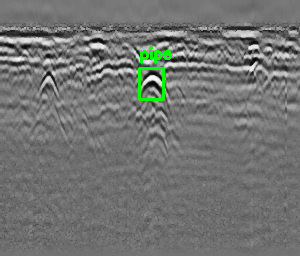

(np.float64(-0.5), np.float64(299.5), np.float64(255.5), np.float64(-0.5))

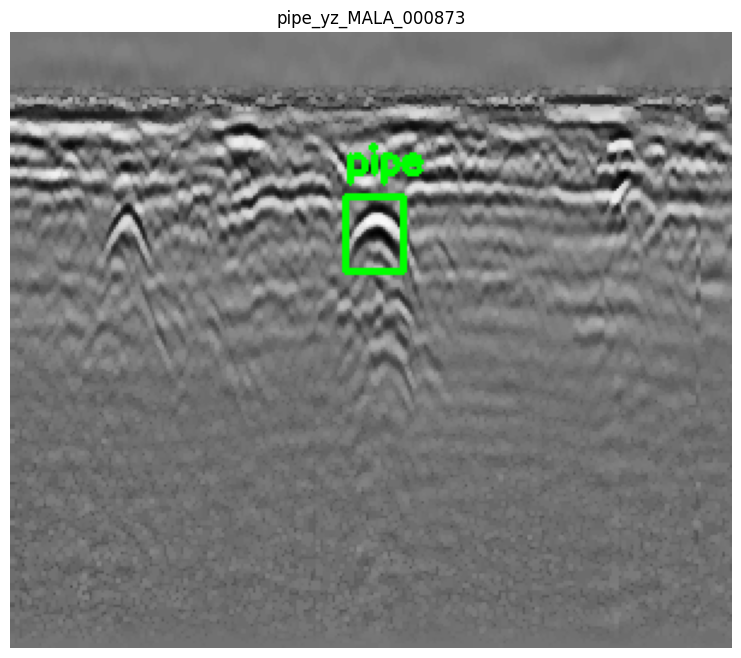

In [ ]:
# 사용 예시
result = process_gpr_with_bbox(gpr_v2_5_topology_optimized,'/content/drive/MyDrive/TDA/dataset/images/train/pipe_yz_MALA_000049.jpg', '/content/drive/MyDrive/TDA/dataset/labels/train_json/pipe_yz_MALA_000049.json')
cv2_imshow(result)

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("pipe_yz_MALA_000873")
plt.axis('off')

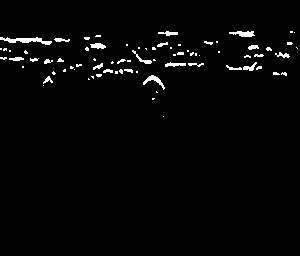

103
128
217
41
42
44
97
63
98
55


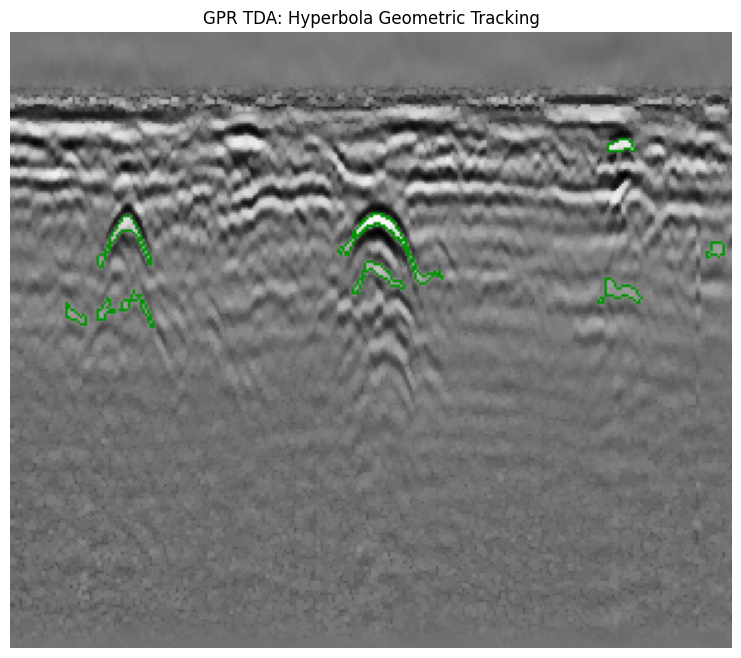

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

def analyze_gpr_tda_v2(image_path, num_seeds=200, start_threshold=190, step=2):
    # 1. 이미지 로드
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("이미지를 찾을 수 없습니다.")
        return

    # 2. 초기 High-level Seed 생성 (가장 밝은 영역)
    _, initial_mask = cv2.threshold(img, start_threshold, 255, cv2.THRESH_BINARY)
    cv2_imshow(initial_mask)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(initial_mask)

    # 면적 순으로 정렬하여 상위 n개만 넘버링 (배경 제외)
    sorted_idx = np.argsort(stats[1:, cv2.CC_STAT_AREA])[::-1][:num_seeds]
    seeds = {i+1: {'label': i+1, 'last_area': stats[idx+1, cv2.CC_STAT_AREA],
                   'is_valid': True,'is_frozen': False, 'final_mask': None,"initial":True} for i, idx in enumerate(sorted_idx)}

    # 초기 레이블 재설정 및 초기 마스크 저장 (시작하자마자 얼어버릴 경우를 대비)
    current_labels = np.zeros_like(labels)
    for i, idx in enumerate(sorted_idx):
        s_id = i + 1
        current_labels[labels == idx+1] = s_id
        seeds[s_id]['final_mask'] = (current_labels == s_id).astype(np.uint8) * 255

    # 3. Filtration 진행 (임계값을 낮추며 확장)
    for t in range(start_threshold - step, 130, -step):
        _, current_mask = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)
        num_objects, labels_map, temp_stats, _ = cv2.connectedComponentsWithStats(current_mask)
        #cv2_imshow(current_mask)
        # 딕셔너리를 순회할 때, 크기가 변할 수 있으므로 list로 감싸서 순회합니다.

        # ----------------------------------------------------
        # [A] 기존 씨앗들 확장 및 검사 (기존 로직)
        # ----------------------------------------------------
        for s_id in list(seeds.keys()):
            info = seeds[s_id]
            #is_hyperbola =False
            # 이미 탈락한 씨앗은 무시
            if not info['is_valid'] or info['is_frozen']:
                continue

            # 현재 추적 중인 객체의 픽셀 위치
            y, x = np.where(current_labels == s_id)
            if len(y) == 0: continue

            # 현재 임계값 t에서 씨앗 중심점이 속한 새로운 영역 탐색
            target_row, target_col = int(y[0]), int(x[0])
            new_label_at_seed = labels_map[target_row, target_col]
            if new_label_at_seed == 0: continue

            # ==========================================
            # 1. temp_stats에서 면적(Area)과 너비(Width) 추출
            # ==========================================
            new_area = temp_stats[new_label_at_seed, cv2.CC_STAT_AREA]

            # ==========================================
            # 2. 면적 제한 조건 (6864 초과 시 확장 강제 종료)
            # ==========================================
            if new_area > 6864:
                # 확장을 멈추는 것이 아니라 아예 탈락시킴
                info['is_valid'] = False
                info['final_mask'] = None # 아예 제거
                current_labels[current_labels == s_id] = 0 # 이미지 맵에서도 지움
                continue



            # 새로운 영역의 전체 픽셀 좌표 가져오기
            new_width = temp_stats[new_label_at_seed, cv2.CC_STAT_WIDTH]
            pts_y, pts_x = np.where(labels_map == new_label_at_seed)

            # --- [기하학적(쌍곡선) 조건 분석 파트 시작] ---
            # 객체의 너비가 너무 작으면(점 형태) 아직 기울기나 형태를 판단하기 어려우므로 무조건 확장시킴
            #width = np.max(pts_x) - np.min(pts_x)

            if new_width < 10:
                is_hyperbola = True
            else:
                # 최좌단(Left), 최우단(Right) 좌표 찾기
                min_x_idx, max_x_idx = np.argmin(pts_x), np.argmax(pts_x)
                lx, ly = pts_x[min_x_idx], pts_y[min_x_idx]
                rx, ry = pts_x[max_x_idx], pts_y[max_x_idx]

                # 가운데 부분 추출 (중심 x 좌표 기준 ±10% 범위)
                cx = np.mean(pts_x)
                center_margin = max(0, int(new_width * 0.18))
                center_mask = (pts_x >= cx - center_margin) & (pts_x <= cx + center_margin)

                center_pts_y = pts_y[center_mask]
                center_pts_x = pts_x[center_mask]

                if len(center_pts_y) == 0:
                    is_hyperbola = False
                else:
                    # 가운데 최상단(y가 가장 작은 값)과 최하단(y가 가장 큰 값)
                    apex_idx = np.argmin(center_pts_y)
                    apex_x, apex_y = center_pts_x[apex_idx], center_pts_y[apex_idx]
                    c_bottom_y = np.max(center_pts_y)

                    # 조건 1: 가운데 최상단이 양 끝점보다 위에 있어야 함 (y좌표가 작아야 함)
                    # (만약 엎어진 U자가 아니라 V자를 찾으신다면 apex_y > ly 로 부등호 변경)
                    cond1 = (apex_y <= ly) and (apex_y <= ry)

                    # 조건 2: 가운데 최하단이 양 끝점과 같거나 더 아래(y좌표가 큼)에 있어야 함
                    cond2 = (c_bottom_y <= ly) and (c_bottom_y <= ry)

                    # 조건 3: 최우단과 가운데 최상단의 기울기 (0.3 ~ 6.2)
                    dx = rx - apex_x
                    dy = ry - apex_y
                    dx_l = lx - apex_x
                    dy_l = ly - apex_y

                    if dx == 0:
                        slope = 9999.0 # 수직인 경우 (에러 방지)
                        slope1 = -99999.0
                    else:
                        slope = abs(dy / dx)
                        slope1 = - abs(dy_l/dx_l)

                    cond3 = (0.3 <= slope <= 6.2)

                    cond4 = (-6.2 <= slope1<=-0.3)


                    # 세 조건을 모두 만족해야 쌍곡선으로 인정
                    is_hyperbola = cond1 and cond2 and cond3 and cond4
                    passed_geometric_test = True # 기하학적 검사를 수행함
            # --- [기하학적 분석 파트 끝] ---

            # 4. 판별 결과에 따른 업데이트
            if is_hyperbola:
                # 조건을 만족하면 계속 확장
                current_labels[labels_map == new_label_at_seed] = s_id
                info['last_area'] = new_area
                info['final_mask'] = (current_labels == s_id).astype(np.uint8) * 255

                # [핵심 수정] 너비가 10 이상이 되어 실제 검사를 통과했을 때만 initial 딱지를 뗌
                if passed_geometric_test:
                    info["initial"] = False
            else:
                # [핵심] 조건을 만족하지 못하면 확장을 멈춤(Frozen).
                # current_labels와 final_mask를 덮어쓰지 않으므로 '이전 픽셀값'의 정상 상태가 그대로 유지됨.
                info['is_frozen'] = True
                if info["initial"]:
                  info['is_valid'] = False
                  info['final_mask'] = None # 이전 임계값에서 얻은 정상 마스크도 완전히 폐기
                  current_labels[current_labels == s_id] = 0 # 추적 맵에서 흔적을 지움

        # ----------------------------------------------------
        # [B] 임계값이 낮아지면서 새롭게 등장한 씨앗(New Seed) 탐색 및 등록
        # ----------------------------------------------------
        # 새롭게 부여할 ID (현재 존재하는 ID 중 가장 큰 값 + 1)
        next_seed_id = max(seeds.keys()) + 1 if seeds else 1

        # 현재 임계값의 전체 객체(labels_map)를 순회 (0번 배경 제외)
        for k in range(1, num_objects):
            mask_k = (labels_map == k)

            # [핵심] 해당 객체 영역 내에 '현재 추적 중인 레이블(current_labels)'이 전혀 없는지 확인
            # 즉, 값이 0이라는 것은 어떤 기존 객체와도 겹치지 않는 완전한 새로운 독립 객체임을 의미
            if np.max(current_labels[mask_k]) == 0:
                new_area = temp_stats[k, cv2.CC_STAT_AREA]

                # 너무 큰 면적은 애초에 노이즈이므로 새로운 씨앗으로 취급하지 않음
                if new_area > 6864:
                    continue

                # 새로운 객체 등록 (현재 위치를 새로운 ID로 색칠)
                current_labels[mask_k] = next_seed_id
                seeds[next_seed_id] = {
                    'label': next_seed_id,
                    'last_area': new_area,
                    'is_valid': True,
                    'is_frozen': False,
                    'final_mask': (current_labels == next_seed_id).astype(np.uint8) * 255,
                    'initial': True
                }
                next_seed_id += 1 # 다음 새로운 객체를 위해 ID 증가


    # 5. 결과 시각화 (객체별 선 마킹)
    result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    line_color = (0, 150, 0)

    for s_id, info in seeds.items():
        # 확장이 끝난 마스크를 가져옴
        # [최소 넓이 조건 필터링]: 최종적으로 30 이하로 멈춘 찌꺼기 노이즈는 그리지 않음

        if info['last_area'] <= 40:
            continue

        # 쌍곡선 형태가 깨져서 삭제(None)된 객체는 그리지 않음
        if info['final_mask'] is None:
            continue
        print(info['last_area'])
        contours, _ = cv2.findContours(info['final_mask'], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(result_img, contours, -1, line_color, 1)

    return result_img


# 실행 및 출력
image_path = '/content/drive/MyDrive/TDA/dataset/images/train_signal_v2/pipe_yz_MALA_000049.jpg'
output = analyze_gpr_tda_v2(image_path)

if output is not None:
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.title("GPR TDA: Hyperbola Geometric Tracking")
    plt.axis('off')
    plt.show()

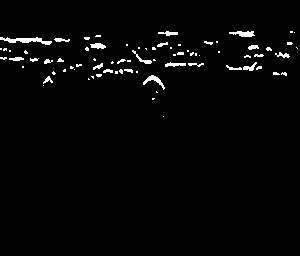

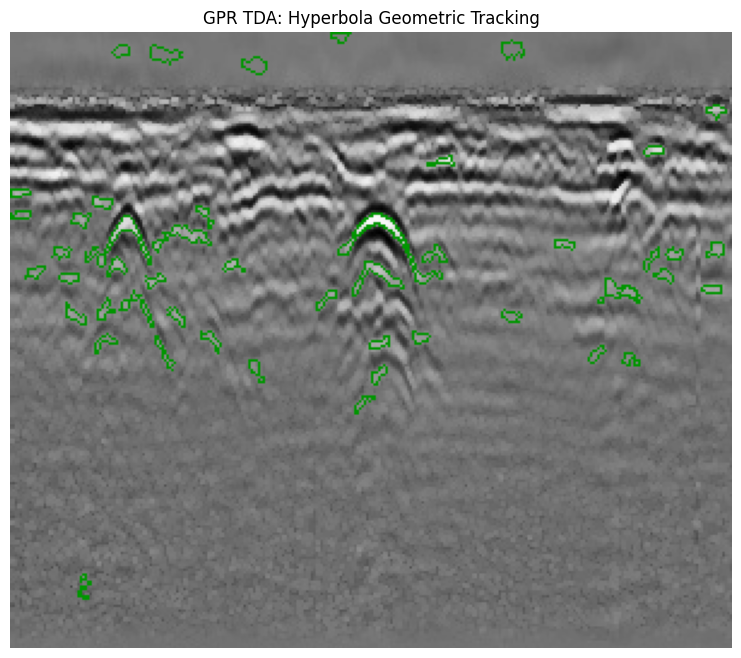

In [ ]:
# 실행 및 출력
image_path = '/content/drive/MyDrive/TDA/dataset/images/train_signal_v2/pipe_yz_MALA_000049.jpg'
output = analyze_gpr_tda_v2(image_path)

if output is not None:
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.title("GPR TDA: Hyperbola Geometric Tracking")
    plt.axis('off')
    plt.show()

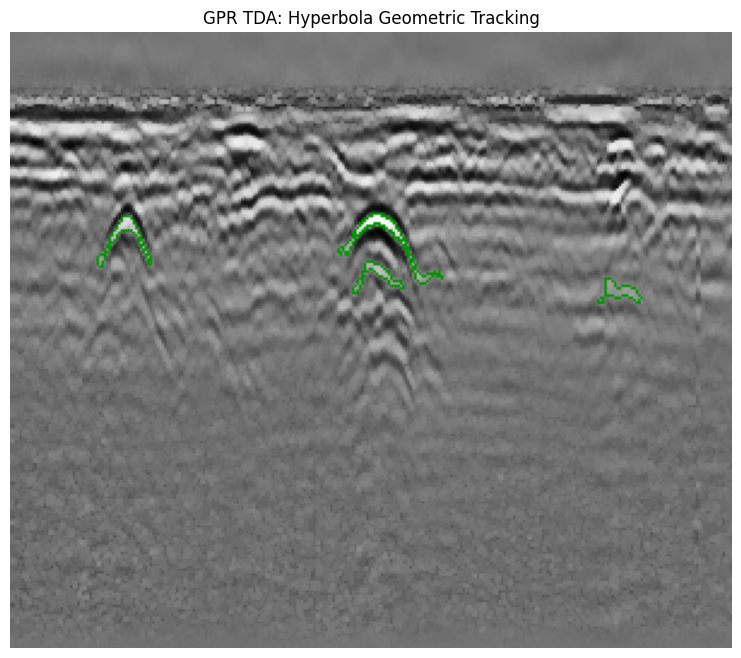

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

def analyze_gpr_tda_v2(image_path, num_seeds=200, start_threshold=190, step=2):
    # 1. 이미지 로드
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("이미지를 찾을 수 없습니다.")
        return

    rows, cols = img.shape
    #print( rows*cols)
    total_pixel_area = rows * cols  # 이미지의 전체 픽셀 수

    # [설정] 기준 해상도(300x256)에서의 6864 픽셀을 비율로 환산
    # 기준 비율 = 6864 / (300 * 256) ≒ 0.089375 (약 8.9%)
    MAX_AREA_RATIO = 0.08
    MIN_WIDTH_RATIO = 0.03  # 기준 너비 비율 (약 3.3%)


    # 2. 초기 High-level Seed 생성 (가장 밝은 영역)
    _, initial_mask = cv2.threshold(img, start_threshold, 255, cv2.THRESH_BINARY)
    # cv2_imshow(initial_mask)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(initial_mask)

    # 면적 순으로 정렬하여 상위 n개만 넘버링 (배경 제외)
    sorted_idx = np.argsort(stats[1:, cv2.CC_STAT_AREA])[::-1][:num_seeds]
    seeds = {i+1: {'label': i+1, 'last_area': stats[idx+1, cv2.CC_STAT_AREA],
                   'is_valid': True,'is_frozen': False, 'final_mask': None,"initial":True} for i, idx in enumerate(sorted_idx)}

    # 초기 레이블 재설정 및 초기 마스크 저장 (시작하자마자 얼어버릴 경우를 대비)
    current_labels = np.zeros_like(labels)
    for i, idx in enumerate(sorted_idx):
        s_id = i + 1
        current_labels[labels == idx+1] = s_id
        seeds[s_id]['final_mask'] = (current_labels == s_id).astype(np.uint8) * 255

    # 3. Filtration 진행 (임계값을 낮추며 확장)
    for t in range(start_threshold - step, 130, -step):
        _, current_mask = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)
        num_objects, labels_map, temp_stats, _ = cv2.connectedComponentsWithStats(current_mask)
        #cv2_imshow(current_mask)
        # 딕셔너리를 순회할 때, 크기가 변할 수 있으므로 list로 감싸서 순회합니다.

        # ----------------------------------------------------
        # [A] 기존 씨앗들 확장 및 검사 (기존 로직)
        # ----------------------------------------------------
        for s_id in list(seeds.keys()):
            info = seeds[s_id]
            #is_hyperbola =False
            # 이미 탈락한 씨앗은 무시
            if not info['is_valid'] or info['is_frozen']:
                continue

            # 현재 추적 중인 객체의 픽셀 위치
            y, x = np.where(current_labels == s_id)
            if len(y) == 0: continue

            # 현재 임계값 t에서 씨앗 중심점이 속한 새로운 영역 탐색
            target_row, target_col = int(y[0]), int(x[0])
            new_label_at_seed = labels_map[target_row, target_col]
            if new_label_at_seed == 0: continue

            # ==========================================
            # 1. temp_stats에서 면적(Area)과 너비(Width) 추출
            # ==========================================
            new_area = temp_stats[new_label_at_seed, cv2.CC_STAT_AREA]
            current_area_ratio = new_area / total_pixel_area

            # ==========================================
            # 2. 면적 제한 조건 (6864 초과 시 확장 강제 종료)
            # ==========================================
            if current_area_ratio > MAX_AREA_RATIO:
                # 확장을 멈추는 것이 아니라 아예 탈락시킴
                info['is_valid'] = False
                info['final_mask'] = None # 아예 제거
                current_labels[current_labels == s_id] = 0 # 이미지 맵에서도 지움
                continue



            # 새로운 영역의 전체 픽셀 좌표 가져오기
            new_width = temp_stats[new_label_at_seed, cv2.CC_STAT_WIDTH]
            current_width_ratio = new_width / cols
            pts_y, pts_x = np.where(labels_map == new_label_at_seed)

            # --- [기하학적(쌍곡선) 조건 분석 파트 시작] ---
            # 객체의 너비가 너무 작으면(점 형태) 아직 기울기나 형태를 판단하기 어려우므로 무조건 확장시킴
            #width = np.max(pts_x) - np.min(pts_x)

            # [수정 2] 변수 초기화 추가
            passed_geometric_test = False
            is_hyperbola = False

            if current_width_ratio < MIN_WIDTH_RATIO:
                is_hyperbola = True
            else:
                # 최좌단(Left), 최우단(Right) 좌표 찾기
                min_x_idx, max_x_idx = np.argmin(pts_x), np.argmax(pts_x)
                lx, ly = pts_x[min_x_idx], pts_y[min_x_idx]
                rx, ry = pts_x[max_x_idx], pts_y[max_x_idx]

                # 가운데 부분 추출 (중심 x 좌표 기준 ±10% 범위)
                cx = np.mean(pts_x)
                center_margin = max(0, int(new_width * 0.18))
                center_mask = (pts_x >= cx - center_margin) & (pts_x <= cx + center_margin)

                center_pts_y = pts_y[center_mask]
                center_pts_x = pts_x[center_mask]

                if len(center_pts_y) == 0:
                    is_hyperbola = False
                else:
                    # 가운데 최상단(y가 가장 작은 값)과 최하단(y가 가장 큰 값)
                    apex_idx = np.argmin(center_pts_y)
                    apex_x, apex_y = center_pts_x[apex_idx], center_pts_y[apex_idx]
                    c_bottom_y = np.max(center_pts_y)

                    # 조건 1: 가운데 최상단이 양 끝점보다 위에 있어야 함 (y좌표가 작아야 함)
                    # (만약 엎어진 U자가 아니라 V자를 찾으신다면 apex_y > ly 로 부등호 변경)
                    cond1 = (apex_y <= ly) and (apex_y <= ry)

                    # 조건 2: 가운데 최하단이 양 끝점과 같거나 더 아래(y좌표가 큼)에 있어야 함
                    cond2 = (c_bottom_y <= ly) and (c_bottom_y <= ry)

                    # 조건 3: 최우단과 가운데 최상단의 기울기 (0.3 ~ 6.2)
                    dx = rx - apex_x
                    dy = ry - apex_y
                    dx_l = lx - apex_x
                    dy_l = ly - apex_y

                    if dx == 0:
                        slope = 9999.0 # 수직인 경우 (에러 방지)
                        slope1 = -99999.0
                    else:
                        slope = abs(dy / dx)
                        slope1 = - abs(dy_l/dx_l)

                    cond3 = (0.3 <= slope <= 6.2)

                    cond4 = (-6.2 <= slope1<=-0.3)


                    # 세 조건을 모두 만족해야 쌍곡선으로 인정
                    is_hyperbola = cond1 and cond2 and cond3 and cond4
                    passed_geometric_test = True # 기하학적 검사를 수행함
            # --- [기하학적 분석 파트 끝] ---

            # 4. 판별 결과에 따른 업데이트
            if is_hyperbola:
                # 조건을 만족하면 계속 확장
                current_labels[labels_map == new_label_at_seed] = s_id
                info['last_area'] = new_area
                info['final_mask'] = (current_labels == s_id).astype(np.uint8) * 255

                # [핵심 수정] 너비가 10 이상이 되어 실제 검사를 통과했을 때만 initial 딱지를 뗌
                if passed_geometric_test:
                    info["initial"] = False
            else:
                # [핵심] 조건을 만족하지 못하면 확장을 멈춤(Frozen).
                # current_labels와 final_mask를 덮어쓰지 않으므로 '이전 픽셀값'의 정상 상태가 그대로 유지됨.
                info['is_frozen'] = True
                if info["initial"]:
                  info['is_valid'] = False
                  info['final_mask'] = None # 이전 임계값에서 얻은 정상 마스크도 완전히 폐기
                  current_labels[current_labels == s_id] = 0 # 추적 맵에서 흔적을 지움

        # ----------------------------------------------------
        # [B] 임계값이 낮아지면서 새롭게 등장한 씨앗(New Seed) 탐색 및 등록
        # ----------------------------------------------------
        # 새롭게 부여할 ID (현재 존재하는 ID 중 가장 큰 값 + 1)
        next_seed_id = max(seeds.keys()) + 1 if seeds else 1

        # 현재 임계값의 전체 객체(labels_map)를 순회 (0번 배경 제외)
        for k in range(1, num_objects):
            mask_k = (labels_map == k)

            # [핵심] 해당 객체 영역 내에 '현재 추적 중인 레이블(current_labels)'이 전혀 없는지 확인
            # 즉, 값이 0이라는 것은 어떤 기존 객체와도 겹치지 않는 완전한 새로운 독립 객체임을 의미
            if np.max(current_labels[mask_k]) == 0:
                new_area = temp_stats[k, cv2.CC_STAT_AREA]

                # 너무 큰 면적은 애초에 노이즈이므로 새로운 씨앗으로 취급하지 않음
                if (new_area / total_pixel_area) > MAX_AREA_RATIO:
                    continue

                # 새로운 객체 등록 (현재 위치를 새로운 ID로 색칠)
                current_labels[mask_k] = next_seed_id
                seeds[next_seed_id] = {
                    'label': next_seed_id,
                    'last_area': new_area,
                    'is_valid': True,
                    'is_frozen': False,
                    'final_mask': (current_labels == next_seed_id).astype(np.uint8) * 255,
                    'initial': True
                }
                next_seed_id += 1 # 다음 새로운 객체를 위해 ID 증가


    # 5. 결과 시각화 (객체별 선 마킹)
    result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    line_color = (0, 150, 0)

    for s_id, info in seeds.items():
        # 확장이 끝난 마스크를 가져옴
        # [최소 넓이 조건 필터링]: 최종적으로 30 이하로 멈춘 찌꺼기 노이즈는 그리지 않음
        if info['initial']:
            continue

        if info['last_area']/(rows*cols) <= 80/(rows*cols):
            continue

        # 쌍곡선 형태가 깨져서 삭제(None)된 객체는 그리지 않음
        if not info['is_valid'] or info['final_mask'] is None:
            continue
        #print(info['last_area'])
        contours, _ = cv2.findContours(info['final_mask'], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        cv2.drawContours(result_img, contours, -1, line_color, 1)

    return result_img


# 실행 및 출력
image_path = '/content/drive/MyDrive/TDA/dataset/images/train_signal_v2/pipe_yz_MALA_000049.jpg'
output = analyze_gpr_tda_v2(image_path)

if output is not None:
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.title("GPR TDA: Hyperbola Geometric Tracking")
    plt.axis('off')
    plt.show()

## Remake 5/5 속도 개선, 비율로

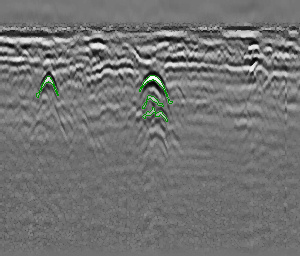

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

def analyze_gpr_tda_v3(image_path, num_seeds=200, start_threshold=190, step=2):
    # 1. 이미지 로드
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("이미지를 찾을 수 없습니다.")
        return

    rows, cols = img.shape
    total_pixel_area = rows * cols

    # [설정] 비율 기반 임계값
    MAX_AREA_RATIO = 0.08
    MIN_WIDTH_RATIO = 0.04
    MIN_DRAW_AREA = 80 # 최종 출력 시 최소 픽셀 수

    # 2. 초기 High-level Seed 생성
    _, initial_mask = cv2.threshold(img, start_threshold, 255, cv2.THRESH_BINARY)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(initial_mask)

    sorted_idx = np.argsort(stats[1:, cv2.CC_STAT_AREA])[::-1][:num_seeds]

    seeds = {}
    # current_labels는 추적 중인 객체의 ID를 기록하는 맵입니다.
    current_labels_map = np.zeros_like(labels, dtype=np.int32)

    for i, idx in enumerate(sorted_idx):
        s_id = i + 1
        label_idx = idx + 1
        current_labels_map[labels == label_idx] = s_id

        # 최적화 핵심: 씨앗의 위치를 찾기 위해 np.where를 쓰는 대신 무게중심 좌표를 저장
        cy, cx = int(centroids[label_idx][1]), int(centroids[label_idx][0])

        seeds[s_id] = {
            'label': s_id,
            'anchor_pt': (cy, cx), # 추적용 고정 좌표
            'last_area': stats[label_idx, cv2.CC_STAT_AREA],
            'is_valid': True,
            'is_frozen': False,
            'final_mask': (labels == label_idx).astype(np.uint8) * 255,
            'initial': True
        }

    # 3. Filtration 진행 (임계값을 낮추며 확장)
    for t in range(start_threshold - step, 130, -step):
        _, current_mask = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)
        num_objects, labels_map, temp_stats, temp_centroids = cv2.connectedComponentsWithStats(current_mask)

        # ----------------------------------------------------
        # [A] 기존 씨앗들 확장 및 검증
        # ----------------------------------------------------
        for s_id in list(seeds.keys()):
            info = seeds[s_id]
            if not info['is_valid'] or info['is_frozen']: continue

            # 앵커 포인트를 이용해 현재 임계값 맵에서 어떤 객체에 속하는지 즉시 확인
            cy, cx = info['anchor_pt']
            new_label = labels_map[cy, cx]

            if new_label == 0:
                continue

            # 면적 확인
            new_area = temp_stats[new_label, cv2.CC_STAT_AREA]
            if (new_area / total_pixel_area) > MAX_AREA_RATIO:
                info['is_valid'] = False
                info['final_mask'] = None
                continue

            new_width = temp_stats[new_label, cv2.CC_STAT_WIDTH]
            current_width_ratio = new_width / cols

            # 기하학적 분석
            is_hyperbola = False
            passed_geometric_test = False

            if current_width_ratio < MIN_WIDTH_RATIO:
                is_hyperbola = True # 너무 작으면 일단 유지
            else:
                # Bounding Box 내에서만 좌표 추출 (속도 최적화)
                x_s, y_st, w_s, h_s = temp_stats[new_label, :4]
                roi_labels = labels_map[y_st:y_st+h_s, x_s:x_s+w_s]
                pts_y, pts_x = np.where(roi_labels == new_label)
                pts_y += y_st
                pts_x += x_s

                min_x_idx, max_x_idx = np.argmin(pts_x), np.argmax(pts_x)
                lx, ly = pts_x[min_x_idx], pts_y[min_x_idx]
                rx, ry = pts_x[max_x_idx], pts_y[max_x_idx]

                obj_cx = x_s + w_s / 2
                center_margin = max(0, int(new_width * 0.18))
                center_mask = (pts_x >= obj_cx - center_margin) & (pts_x <= obj_cx + center_margin)

                if np.any(center_mask):
                    c_pts_y = pts_y[center_mask]
                    c_pts_x = pts_x[center_mask]
                    apex_idx = np.argmin(c_pts_y)
                    apex_x, apex_y = c_pts_x[apex_idx], c_pts_y[apex_idx]
                    c_bottom_y = np.max(c_pts_y)

                    cond1 = (apex_y <= ly) and (apex_y <= ry)
                    cond2 = (c_bottom_y <= ly) and (c_bottom_y <= ry)

                    dx_r, dy_r = rx - apex_x, ry - apex_y
                    dx_l, dy_l = lx - apex_x, ly - apex_y

                    slope_r = abs(dy_r / dx_r) if dx_r != 0 else 9999.0
                    slope_l = -abs(dy_l / dx_l) if dx_l != 0 else -9999.0

                    if cond1 and cond2 and (0.3 <= slope_r <= 6.2) and (-6.2 <= slope_l <= -0.3):
                        is_hyperbola = True
                        passed_geometric_test = True

            if is_hyperbola:
                info['last_area'] = new_area
                # 다음 단계 추적을 위해 앵커 포인트를 현재 객체의 중심으로 업데이트
                info['anchor_pt'] = (int(temp_centroids[new_label][1]), int(temp_centroids[new_label][0]))
                # 검증 성공 시 마스크 업데이트
                info['final_mask'] = (labels_map == new_label).astype(np.uint8) * 255
                if passed_geometric_test:
                    info["initial"] = False
            else:
                # 조건 탈락 시 '동결'. final_mask는 업데이트되지 않아 이전 상태가 유지됨
                info['is_frozen'] = True
                if info["initial"]:
                    info['is_valid'] = False
                    info['final_mask'] = None

        # ----------------------------------------------------
        # [B] 새로운 씨앗(New Birth) 탐색 및 등록
        # ----------------------------------------------------
        next_id = max(seeds.keys()) + 1 if seeds else 1
        # 현재 labels_map의 객체들 중 기존 씨앗의 앵커 포인트가 없는 곳을 찾음
        for k in range(1, num_objects):
            # 최적화: 새 레이블의 무게중심에 기존 ID가 없으면 새로운 탄생으로 간주
            new_cy, new_cx = int(temp_centroids[k][1]), int(temp_centroids[k][0])
            if current_labels_map[new_cy, new_cx] == 0:
                area_k = temp_stats[k, cv2.CC_STAT_AREA]
                if (area_k / total_pixel_area) <= MAX_AREA_RATIO:
                    seeds[next_id] = {
                        'label': next_id,
                        'anchor_pt': (new_cy, new_cx),
                        'last_area': area_k,
                        'is_valid': True,
                        'is_frozen': False,
                        'final_mask': (labels_map == k).astype(np.uint8) * 255,
                        'initial': True
                    }
                    # 추적 맵에 기록 (겹침 방지)
                    current_labels_map[labels_map == k] = next_id
                    next_id += 1

    # 4. 결과 시각화
    result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    for s_id, info in seeds.items():
        if info['is_valid'] and not info['initial'] and info['final_mask'] is not None:
            if info['last_area'] >= MIN_DRAW_AREA:
                contours, _ = cv2.findContours(info['final_mask'], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                cv2.drawContours(result_img, contours, -1, (0, 150, 0), 1)

    return result_img

# 실행
image_path = '/content/drive/MyDrive/TDA/dataset/images/train_signal_v2/pipe_yz_MALA_000049.jpg'
output = analyze_gpr_tda_v3(image_path)
cv2_imshow(output)

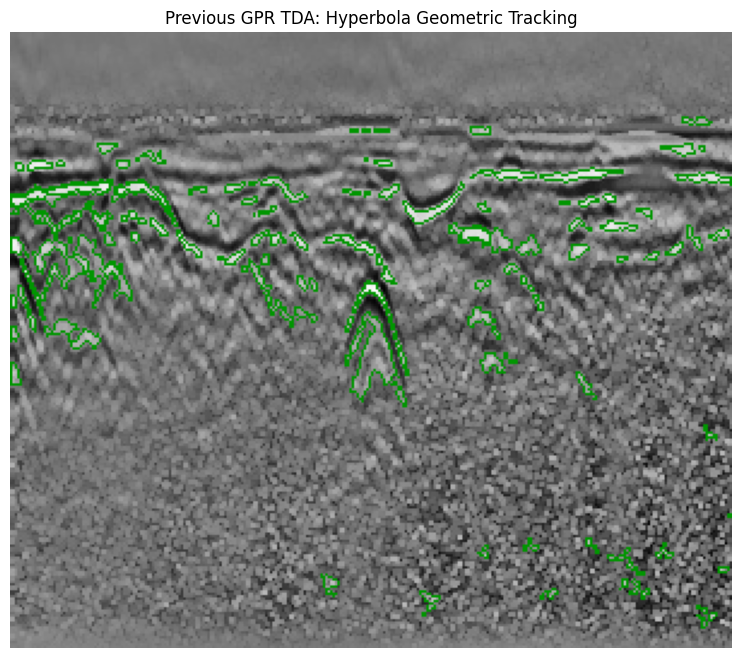

In [ ]:
# 실행 및 출력
image_path = '/content/drive/MyDrive/TDA/dataset/images/train_signal_v2/pipe_yz_MALA_000118.jpg'
output = analyze_gpr_tda_v2(image_path)

if output is not None:
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
    plt.title("Previous GPR TDA: Hyperbola Geometric Tracking")
    plt.axis('off')
    plt.show()

## 1번 테스트

GPR(지표 투과 레이더) 이미지에서 High-level set filtration을 적용하여 초기 씨앗(Seed)을 넘버링하고, 임계값이 낮아짐에 따라 영역이 확장되다가 급격히 커지기 직전의 상태를 포착하는 Python 코드를 제안합니다.

이 코드는 단순한 라이브러리 호출을 넘어, 사용자님께서 의도하신 **'객체 독립성 유지'**와 '급격한 변화 포착' 로직을 핵심으로 합니다.

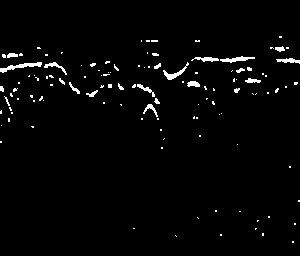

120


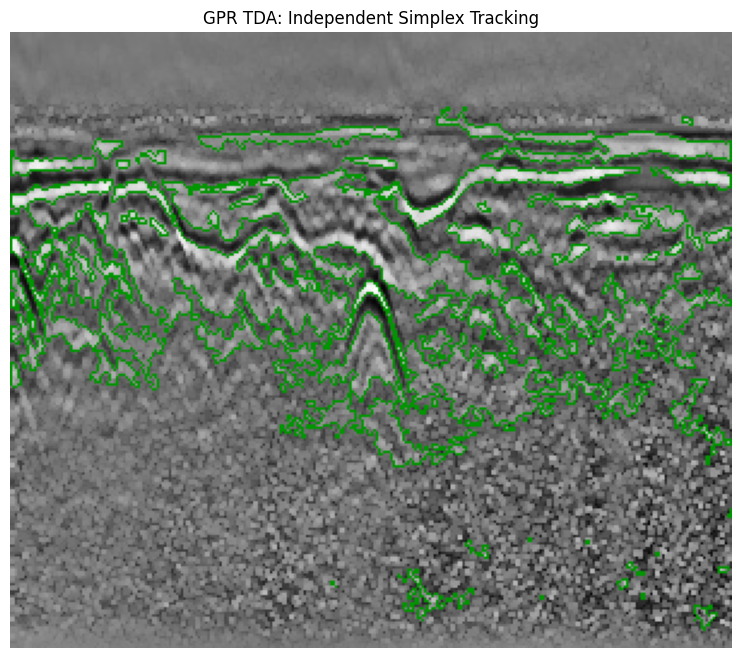

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow # 코랩 전용 이미지 출력 함수 임포트

def analyze_gpr_tda_v1(image_path, num_seeds=200, start_threshold=190, step=2):
    # 1. 이미지 로드 및 전처리
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return print("이미지를 찾을 수 없습니다.")

    # 애매한 부분
    #cv2_imshow(img)
    # 가우시안 블러로 미세 노이즈 제거 (GPR 특성상 노이즈가 많음)
    #img_blur = cv2.GaussianBlur(img, (5, 5), 0)
    # cv2_imshow(img_blur)
    # 해당 부분에 대해서 좀 봐야 할 거 같습니다.

    # 2. 초기 High-level Seed 생성 (가장 밝은 영역 7~10개 추출)
    # _: 적용된 임계값
    # mask: 0과 255로 이루어진 2D 이진 행렬
    _, initial_mask = cv2.threshold(img, start_threshold, 255, cv2.THRESH_BINARY)
    cv2_imshow(initial_mask)

    # input: initial_mask: 특정 임계값 t에서의 이진 행렬
    # return:
    #     - num_labels:(정수) 배경을 포함한 총 연결 성분의 개수
    #     - labels:(2D 행렬) 각 픽셀이 어떤 객체에 속하는지 번호가 매겨진 맵
    #     - stats: (2D 배열) 각 객체의 바운딩 박스 및 면적
    #     - centroids: (2D배열) 각 객체의 무게중심 좌표
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(initial_mask)


    # 면적 순으로 정렬하여 상위 n개만 넘버링 (배경 제외)
    sorted_idx = np.argsort(stats[1:, cv2.CC_STAT_AREA])[::-1][:num_seeds]
    seeds = {i+1: {'label': i+1, 'last_area': stats[idx+1, cv2.CC_STAT_AREA],
                   'is_frozen': False, 'final_mask': None} for i, idx in enumerate(sorted_idx)}

    # 초기 레이블 재설정
    current_labels = np.zeros_like(labels)
    for i, idx in enumerate(sorted_idx):
        current_labels[labels == idx+1] = i+1

    # 3. Filtration 진행 (임계값을 낮추며 확장)
    for t in range(start_threshold - step, 50, -step):
        _, current_mask = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)

        # temp_labels, _, temp_stats, _ = cv2.connectedComponentsWithStats(current_mask)
        # 5개의 인자를 정확히 받아옵니다 (retval, labels, stats, centroids)
        num_objects, labels_map, temp_stats, _ = cv2.connectedComponentsWithStats(current_mask)


        # 각 씨앗별로 확장성 검사
        for s_id, info in seeds.items():
            if info['is_frozen']: continue

            # 현재 객체 영역 픽셀 위치 추출
            y, x = np.where(current_labels == s_id)
            if len(y) == 0: continue

            # 현재 임계값 t에서 이 객체가 속한 새로운 영역의 크기 확인
            # (씨앗의 중심점 위치가 포함된 새로운 레이블 탐색)
            target_row, target_col = int(y[0]), int(x[0])
            new_label_at_seed = labels_map[target_row, target_col]
            if new_label_at_seed == 0: continue

            new_area = temp_stats[new_label_at_seed, cv2.CC_STAT_AREA]

            # 4. 급격한 변화 포착 (Area Explosion Detection)
            # 이전 면적 대비 증가율이 일정 수준(예: 1.5배) 이상이면 확장을 멈춤(박제)

            if ((new_area > info['last_area'] *2)): #3: > 5:  # 1.8은 GPR 특성에 따라 조정 가능
                info['is_frozen'] = True
                info['final_mask'] = (current_labels == s_id).astype(np.uint8) * 255
            else:
                # 면적이 완만하게 증가하면 레이블 업데이트
                current_labels[labels_map == new_label_at_seed] = s_id
                info['last_area'] = new_area

        # ==================================================
        # mid result
        '''
        if t %1==0 :
          print(f"\n--- 현재 Threshold(임계값): {t} ---")

          # 방법 B: 내가 추적하고 있는 객체들이 어떻게 자라났는지 누적 지도 보기
          # current_labels 안의 1, 2, 3.. 값들이 눈에 보이도록 (255 / num_seeds)를 곱해 밝기 조절
          scale_factor = max(1, 255 // num_seeds)
          display_labels = (current_labels * scale_factor).astype(np.uint8)

          print("2. 추적 중인 단순체 확장 상태 (current_labels)")
          cv2_imshow(display_labels)
        '''
    # 5. 결과 시각화 (객체별 선 마킹)
    result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    #colors = plt.cm.get_cmap('tab10', num_seeds)
    line_color = (0, 150, 0)

    for s_id, info in seeds.items():
        mask = info['final_mask'] if info['final_mask'] is not None else (current_labels == s_id).astype(np.uint8) * 255
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        # color = [int(c*255) for c in colors(s_id-1)[:3]]
        cv2.drawContours(result_img, contours, -1, line_color, 1)
        #if len(contours) > 0:
        #    M = cv2.moments(contours[0])
        #    if M["m00"] != 0:
        #        cx, cy = int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])
        #        cv2.putText(result_img, f"ID:{s_id}", (cx, cy-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    #visualize_individual_simplices(seeds, img)

    # 면적 값들만 리스트로 추출
    all_areas = [info['last_area'] for info in seeds.values()]

    '''
    print(f"총 검출 개수: {len(all_areas)}")
    print(f"최대 면적: {np.max(all_areas)} px")
    print(f"최소 면적: {np.min(all_areas)} px")
    print(f"평균 면적: {np.mean(all_areas):.2f} px")
    '''
    return result_img


# 실행
#result = final_gpr_restoration('/content/drive/MyDrive/TDA/dataset/images/train_signal/pipe_yz_MALA_000038.jpg')
#result = final_gpr_restoration('/content/drive/MyDrive/TDA/dataset/images/train_signal/pipe_yz_MALA_000049.jpg')
#result = final_gpr_restoration('/content/drive/MyDrive/TDA/dataset/images/train/pipe_yz_MALA_000038.jpg')
#result = final_gpr_restoration('/content/drive/MyDrive/TDA/dataset/images/train/pipe_yz_MALA_000049.jpg')
# /content/drive/MyDrive/TDA/dataset/images/train_signal_v2
output = analyze_gpr_tda_v1('/content/drive/MyDrive/TDA/dataset/images/train_signal_v2/pipe_yz_MALA_000118.jpg') # pipe_yz_MALA_000038.jpg> 220
                                                                                                                 # pipe_yz_MALA_000076.jpg>190
#plt.figure(figsize=(10, 8))
#plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
#plt.title("GPR TDA: Independent Simplex Tracking")
#plt.axis('off')

#output = analyze_gpr_tda('/content/drive/MyDrive/TDA/dataset/images/train_signal/pipe_yz_MALA_000049.jpg',max_area=300)
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("GPR TDA: Independent Simplex Tracking")
plt.axis('off')
#output = analyze_gpr_tda('/content/drive/MyDrive/TDA/dataset/images/train/pipe_yz_MALA_000038.jpg')
#plt.figure(figsize=(10, 8))
#plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
#plt.title("GPR TDA: Independent Simplex Tracking")
#plt.axis('off')

#output = analyze_gpr_tda('/content/drive/MyDrive/TDA/dataset/images/train/pipe_yz_MALA_000049.jpg')
#plt.figure(figsize=(10, 8))
#plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("GPR TDA: Independent Simplex Tracking")
plt.axis('off')
plt.show()

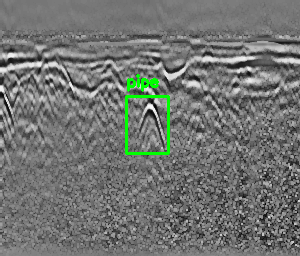

In [ ]:
# 사용 예시
result = process_gpr_with_bbox(gpr_v2_5_topology_optimized,'/content/drive/MyDrive/TDA/dataset/images/train/pipe_yz_MALA_000118.jpg', '/content/drive/MyDrive/TDA/dataset/labels/train_json//pipe_yz_MALA_000118.json')
cv2_imshow(result)

## v2: min area, max area

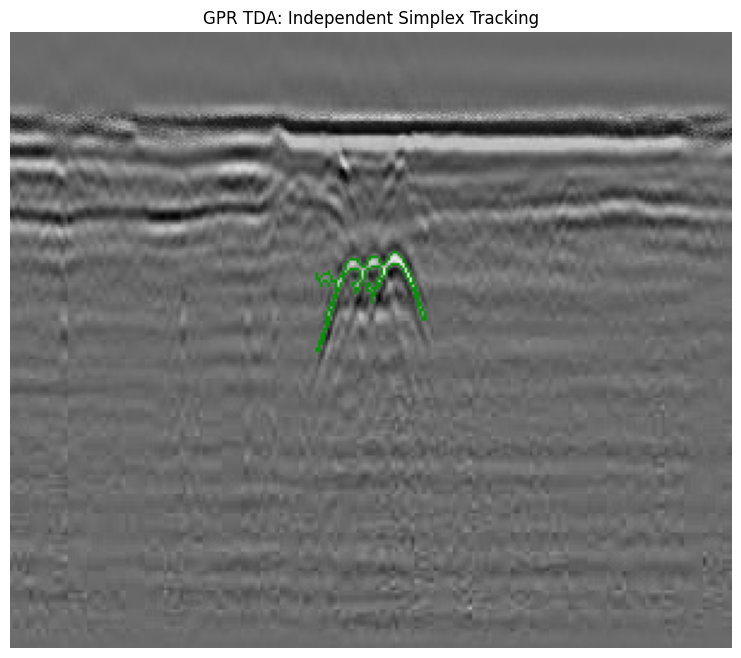

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow # 코랩 전용 이미지 출력 함수 임포트

def analyze_gpr_tda_v2(image_path, num_seeds=300, start_threshold=230, step=2, max_area=350,min_area=20):
    # 1. 이미지 로드 및 전처리
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return print("이미지를 찾을 수 없습니다.")

    # 애매한 부분
    #cv2_imshow(img)
    # 가우시안 블러로 미세 노이즈 제거 (GPR 특성상 노이즈가 많음)
    #img_blur = cv2.GaussianBlur(img, (5, 5), 0)
    # cv2_imshow(img_blur)
    # 해당 부분에 대해서 좀 봐야 할 거 같습니다.

    # 2. 초기 High-level Seed 생성 (가장 밝은 영역 7~10개 추출)
    # _: 적용된 임계값
    # mask: 0과 255로 이루어진 2D 이진 행렬
    _, initial_mask = cv2.threshold(img, start_threshold, 255, cv2.THRESH_BINARY)

    # input: initial_mask: 특정 임계값 t에서의 이진 행렬
    # return:
    #     - num_labels:(정수) 배경을 포함한 총 연결 성분의 개수
    #     - labels:(2D 행렬) 각 픽셀이 어떤 객체에 속하는지 번호가 매겨진 맵
    #     - stats: (2D 배열) 각 객체의 바운딩 박스 및 면적
    #     - centroids: (2D배열) 각 객체의 무게중심 좌표
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(initial_mask)

    # 면적 순으로 정렬하여 상위 n개만 넘버링 (배경 제외)
    sorted_idx = np.argsort(stats[1:, cv2.CC_STAT_AREA])[::-1][:num_seeds]
    seeds = {i+1: {'label': i+1, 'last_area': stats[idx+1, cv2.CC_STAT_AREA],
                   'is_frozen': False, 'final_mask': None} for i, idx in enumerate(sorted_idx)}

    # 초기 레이블 재설정
    current_labels = np.zeros_like(labels)
    for i, idx in enumerate(sorted_idx):
        current_labels[labels == idx+1] = i+1

    # 3. Filtration 진행 (임계값을 낮추며 확장)
    for t in range(start_threshold - step, 50, -step):
        _, current_mask = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)

        # temp_labels, _, temp_stats, _ = cv2.connectedComponentsWithStats(current_mask)
        # 5개의 인자를 정확히 받아옵니다 (retval, labels, stats, centroids)
        num_objects, labels_map, temp_stats, _ = cv2.connectedComponentsWithStats(current_mask)


        # 각 씨앗별로 확장성 검사
        for s_id, info in seeds.items():
            if info['is_frozen']: continue

            # 현재 객체 영역 픽셀 위치 추출
            y, x = np.where(current_labels == s_id)
            if len(y) == 0: continue

            # 현재 임계값 t에서 이 객체가 속한 새로운 영역의 크기 확인
            # (씨앗의 중심점 위치가 포함된 새로운 레이블 탐색)
            target_row, target_col = int(y[0]), int(x[0])
            new_label_at_seed = labels_map[target_row, target_col]
            if new_label_at_seed == 0: continue

            new_area = temp_stats[new_label_at_seed, cv2.CC_STAT_AREA]

            # 4. 급격한 변화 포착 (Area Explosion Detection)
            # 이전 면적 대비 증가율이 일정 수준(예: 1.5배) 이상이면 확장을 멈춤(박제)
            if new_area<min_area:
                current_labels[labels_map == new_label_at_seed] = s_id
                info['last_area'] = new_area
            elif ((new_area > info['last_area'] *3) or (new_area>max_area)): #3: > 5:  # 1.8은 GPR 특성에 따라 조정 가능
                info['is_frozen'] = True
                info['final_mask'] = (current_labels == s_id).astype(np.uint8) * 255
            else:
                # 면적이 완만하게 증가하면 레이블 업데이트
                current_labels[labels_map == new_label_at_seed] = s_id
                info['last_area'] = new_area

        # ==================================================
        # mid result
        '''
        if t %1==0 :
          print(f"\n--- 현재 Threshold(임계값): {t} ---")

          # 방법 B: 내가 추적하고 있는 객체들이 어떻게 자라났는지 누적 지도 보기
          # current_labels 안의 1, 2, 3.. 값들이 눈에 보이도록 (255 / num_seeds)를 곱해 밝기 조절
          scale_factor = max(1, 255 // num_seeds)
          display_labels = (current_labels * scale_factor).astype(np.uint8)

          print("2. 추적 중인 단순체 확장 상태 (current_labels)")
          cv2_imshow(display_labels)
        '''
    # 5. 결과 시각화 (객체별 선 마킹)
    result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    #colors = plt.cm.get_cmap('tab10', num_seeds)
    line_color = (0, 150, 0)

    for s_id, info in seeds.items():
        mask = info['final_mask'] if info['final_mask'] is not None else (current_labels == s_id).astype(np.uint8) * 255
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        # color = [int(c*255) for c in colors(s_id-1)[:3]]
        cv2.drawContours(result_img, contours, -1, line_color, 1)
        #if len(contours) > 0:
        #    M = cv2.moments(contours[0])
        #    if M["m00"] != 0:
        #        cx, cy = int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])
        #        cv2.putText(result_img, f"ID:{s_id}", (cx, cy-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    #visualize_individual_simplices(seeds, img)

    # 면적 값들만 리스트로 추출
    all_areas = [info['last_area'] for info in seeds.values()]


    #print(f"총 검출 개수: {len(all_areas)}")
    #print(f"최대 면적: {np.max(all_areas)} px")
    #print(f"최소 면적: {np.min(all_areas)} px")
    #print(f"평균 면적: {np.mean(all_areas):.2f} px")

    return result_img

def visualize_individual_simplices(seeds, original_img):
    # 'frozen' 상태이거나 마스크가 존재하는 객체들만 필터링
    detected_objects = [info for info in seeds.values() if info['final_mask'] is not None]
    print(len(detected_objects))
    if not detected_objects:
        print("추출된 단순체 모형이 없습니다.")
        return

    num_obj = len(detected_objects)
    cols = 5
    rows = (num_obj // cols) + (1 if num_obj % cols != 0 else 0)

    plt.figure(figsize=(cols * 3, rows * 3))

    for i, info in enumerate(detected_objects):
        # 1. 개별 마스크 가져오기
        mask = info['final_mask']

        # 2. 원본 이미지에서 해당 영역만 추출 (Masking)
        # 마스크 외의 영역은 검은색으로 처리됨
        extracted_simplex = cv2.bitwise_and(original_img, original_img, mask=mask)

        # 3. 객체가 있는 부분만 크롭(Crop)하여 더 자세히 보기
        y, x = np.where(mask > 0)
        top, bottom, left, right = np.min(y), np.max(y), np.min(x), np.max(x)
        cropped_simplex = extracted_simplex[top:bottom+1, left:right+1]

        # 4. 시각화
        plt.subplot(rows, cols, i + 1)
        plt.imshow(cropped_simplex, cmap='gray')
        plt.title(f"Simplex ID: {info['label']}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# 실행
output = analyze_gpr_tda_v2('/content/drive/MyDrive/TDA/dataset/images/train_signal/pipe_yz_MALA_000038.jpg')
#plt.figure(figsize=(10, 8))
#plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
#plt.title("GPR TDA: Independent Simplex Tracking")
#plt.axis('off')

#output = analyze_gpr_tda_v2('/content/drive/MyDrive/TDA/dataset/images/train_signal/pipe_yz_MALA_000049.jpg',max_area=300)
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("GPR TDA: Independent Simplex Tracking")
plt.axis('off')
#output = analyze_gpr_tda_v2('/content/drive/MyDrive/TDA/dataset/images/train/pipe_yz_MALA_000038.jpg')
#plt.figure(figsize=(10, 8))
#plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
#plt.title("GPR TDA: Independent Simplex Tracking")
#plt.axis('off')

#output = analyze_gpr_tda_v2('/content/drive/MyDrive/TDA/dataset/images/train/pipe_yz_MALA_000049.jpg')
#plt.figure(figsize=(10, 8))
#plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("GPR TDA: Independent Simplex Tracking")
plt.axis('off')
plt.show()

## v3 : 양방향 다크한 부분도 가져오기

총 검출 (Bright+Dark): 8
최대 면적: 234 px


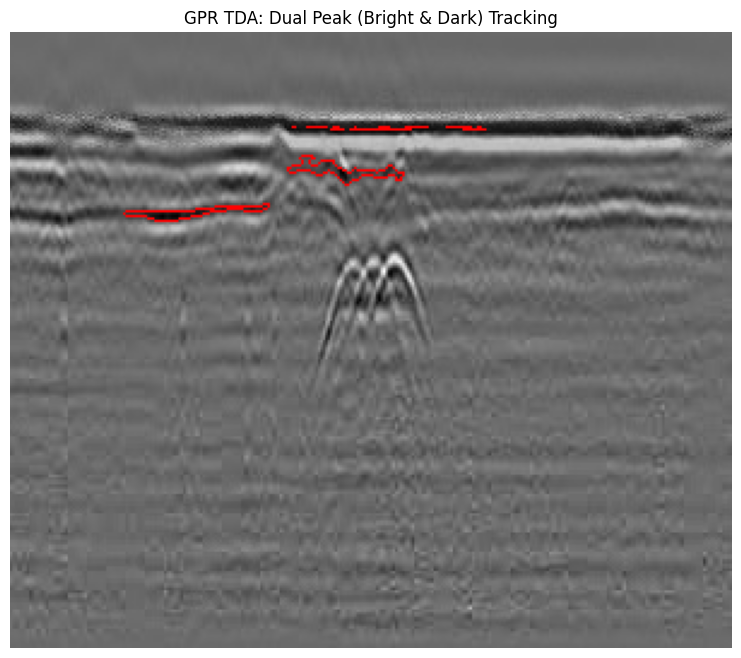

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

def analyze_gpr_tda_dual(image_path, num_seeds=300, start_high=230, start_low=25, step=2, max_area=320, min_area=30):
    # 1. 이미지 로드 및 전처리
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return print("이미지를 찾을 수 없습니다.")

    #img_blur = cv2.GaussianBlur(img, (5, 5), 0)
    mean_val = np.mean(img_blur) # 확장의 정지 기준점 (배경 레벨)

    # 결과를 담을 딕셔너리와 이미지 준비
    all_seeds = {}
    result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    # [탐지 루틴] - Bright 영역(Positive)과 Dark 영역(Negative)을 각각 수행
    modes = [
        {'name': 'Bright', 'start': start_high, 'step': -step, 'thresh_type': cv2.THRESH_BINARY, 'stop': int(mean_val + 10)},
        {'name': 'Dark', 'start': start_low, 'step': step, 'thresh_type': cv2.THRESH_BINARY_INV, 'stop': int(mean_val - 10)}
    ]

    global_seed_count = 1

    for mode in modes:
        # A. 초기 Seed 생성
        _, initial_mask = cv2.threshold(img_blur, mode['start'], 255, mode['thresh_type'])
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(initial_mask)

        sorted_idx = np.argsort(stats[1:, cv2.CC_STAT_AREA])[::-1][:num_seeds]

        current_labels = np.zeros_like(labels)
        mode_seeds = {}

        for i, idx in enumerate(sorted_idx):
            s_id = global_seed_count
            mode_seeds[s_id] = {
                'label': s_id,
                'last_area': stats[idx+1, cv2.CC_STAT_AREA],
                'is_frozen': False,
                'final_mask': None,
                'type': mode['name']
            }
            current_labels[labels == idx+1] = s_id
            global_seed_count += 1

        # B. Filtration 진행
        # Bright는 아래로(230->130), Dark는 위로(25->120)
        target_range = range(mode['start'] + mode['step'], mode['stop'], mode['step'])

        for t in target_range:
            _, current_mask = cv2.threshold(img_blur, t, 255, mode['thresh_type'])
            _, labels_map, temp_stats, _ = cv2.connectedComponentsWithStats(current_mask)

            for s_id, info in mode_seeds.items():
                if info['is_frozen']: continue

                y, x = np.where(current_labels == s_id)
                if len(y) == 0: continue

                new_label_at_seed = labels_map[int(y[0]), int(x[0])]
                if new_label_at_seed == 0: continue

                new_area = temp_stats[new_label_at_seed, cv2.CC_STAT_AREA]

                # Dead 조건 적용
                if new_area < min_area:
                    current_labels[labels_map == new_label_at_seed] = s_id
                    info['last_area'] = new_area
                elif (new_area > info['last_area'] * 2) or (new_area > max_area):
                    info['is_frozen'] = True
                    info['final_mask'] = (current_labels == s_id).astype(np.uint8) * 255
                else:
                    current_labels[labels_map == new_label_at_seed] = s_id
                    info['last_area'] = new_area

        all_seeds.update(mode_seeds)

    # 2. 결과 통합 시각화
    for s_id, info in all_seeds.items():
        mask = info['final_mask'] if info['final_mask'] is not None else (current_labels == s_id).astype(np.uint8) * 255
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # 색상 구분: Bright(녹색), Dark(빨간색)
        color = (0, 255, 0) if info['type'] == 'Bright' else (0, 0, 255)
        cv2.drawContours(result_img, contours, -1, color, 1)

    # 통계 출력
    areas = [info['last_area'] for info in all_seeds.values()]
    print(f"총 검출 (Bright+Dark): {len(areas)}")
    print(f"최대 면적: {np.max(areas) if areas else 0} px")

    return result_img

# 실행 및 시각화
output = analyze_gpr_tda_dual('/content/drive/MyDrive/TDA/dataset/images/train_signal/pipe_yz_MALA_000038.jpg')

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("GPR TDA: Dual Peak (Bright & Dark) Tracking")
plt.axis('off')
plt.show()

## V3: 어두운 걸 기준

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow # 코랩 전용 이미지 출력 함수 임포트

def analyze_gpr_tda_black(image_path, num_seeds=300, start_threshold=10, step=2, max_area=800,min_area=20):
    # 1. 이미지 로드 및 전처리
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return print("이미지를 찾을 수 없습니다.")

    # 애매한 부분
    #cv2_imshow(img)
    # 가우시안 블러로 미세 노이즈 제거 (GPR 특성상 노이즈가 많음)
    img_blur = cv2.GaussianBlur(img, (5, 5), 0)
    # cv2_imshow(img_blur)
    # 해당 부분에 대해서 좀 봐야 할 거 같습니다.

    # 2. 초기 High-level Seed 생성 (가장 밝은 영역 7~10개 추출)
    # _: 적용된 임계값
    # mask: 0과 255로 이루어진 2D 이진 행렬
    _, initial_mask = cv2.threshold(img, start_threshold, 255, cv2.THRESH_BINARY_INV)

    # input: initial_mask: 특정 임계값 t에서의 이진 행렬
    # return:
    #     - num_labels:(정수) 배경을 포함한 총 연결 성분의 개수
    #     - labels:(2D 행렬) 각 픽셀이 어떤 객체에 속하는지 번호가 매겨진 맵
    #     - stats: (2D 배열) 각 객체의 바운딩 박스 및 면적
    #     - centroids: (2D배열) 각 객체의 무게중심 좌표
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(initial_mask)

    # 면적 순으로 정렬하여 상위 n개만 넘버링 (배경 제외)
    sorted_idx = np.argsort(stats[1:, cv2.CC_STAT_AREA])[::-1][:num_seeds]
    seeds = {i+1: {'label': i+1, 'last_area': stats[idx+1, cv2.CC_STAT_AREA],
                   'is_frozen': False, 'final_mask': None} for i, idx in enumerate(sorted_idx)}

    # 초기 레이블 재설정
    current_labels = np.zeros_like(labels)
    for i, idx in enumerate(sorted_idx):
        current_labels[labels == idx+1] = i+1

    # 3. Filtration 진행 (임계값을 낮추며 확장)
    for t in range(start_threshold + step, 230, step):
        _, current_mask = cv2.threshold(img, t, 255, cv2.THRESH_BINARY_INV)

        # temp_labels, _, temp_stats, _ = cv2.connectedComponentsWithStats(current_mask)
        # 5개의 인자를 정확히 받아옵니다 (retval, labels, stats, centroids)
        num_objects, labels_map, temp_stats, _ = cv2.connectedComponentsWithStats(current_mask)


        # 각 씨앗별로 확장성 검사
        for s_id, info in seeds.items():
            if info['is_frozen']: continue

            # 현재 객체 영역 픽셀 위치 추출
            y, x = np.where(current_labels == s_id)
            if len(y) == 0: continue

            # 현재 임계값 t에서 이 객체가 속한 새로운 영역의 크기 확인
            # (씨앗의 중심점 위치가 포함된 새로운 레이블 탐색)
            target_row, target_col = int(y[0]), int(x[0])
            new_label_at_seed = labels_map[target_row, target_col]
            if new_label_at_seed == 0: continue

            new_area = temp_stats[new_label_at_seed, cv2.CC_STAT_AREA]

            # 4. 급격한 변화 포착 (Area Explosion Detection)
            # 이전 면적 대비 증가율이 일정 수준(예: 1.5배) 이상이면 확장을 멈춤(박제)
            if new_area<min_area:
                current_labels[labels_map == new_label_at_seed] = s_id
                info['last_area'] = new_area
            elif ((new_area > info['last_area'] *4) or (new_area>max_area)): #3: > 5:  # 1.8은 GPR 특성에 따라 조정 가능
                info['is_frozen'] = True
                info['final_mask'] = (current_labels == s_id).astype(np.uint8) * 255
            else:
                # 면적이 완만하게 증가하면 레이블 업데이트
                current_labels[labels_map == new_label_at_seed] = s_id
                info['last_area'] = new_area

        # ==================================================
        # mid result
        '''
        if t %1==0 :
          print(f"\n--- 현재 Threshold(임계값): {t} ---")

          # 방법 B: 내가 추적하고 있는 객체들이 어떻게 자라났는지 누적 지도 보기
          # current_labels 안의 1, 2, 3.. 값들이 눈에 보이도록 (255 / num_seeds)를 곱해 밝기 조절
          scale_factor = max(1, 255 // num_seeds)
          display_labels = (current_labels * scale_factor).astype(np.uint8)

          print("2. 추적 중인 단순체 확장 상태 (current_labels)")
          cv2_imshow(display_labels)
        '''
    # 5. 결과 시각화 (객체별 선 마킹)
    result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    #colors = plt.cm.get_cmap('tab10', num_seeds)
    line_color = (0, 0, 150)

    for s_id, info in seeds.items():
        mask = info['final_mask'] if info['final_mask'] is not None else (current_labels == s_id).astype(np.uint8) * 255
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        # color = [int(c*255) for c in colors(s_id-1)[:3]]
        cv2.drawContours(result_img, contours, -1, line_color, 1)
        #if len(contours) > 0:
        #    M = cv2.moments(contours[0])
        #    if M["m00"] != 0:
        #        cx, cy = int(M["m10"]/M["m00"]), int(M["m01"]/M["m00"])
        #        cv2.putText(result_img, f"ID:{s_id}", (cx, cy-10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 2)
    #visualize_individual_simplices(seeds, img)

    # 면적 값들만 리스트로 추출
    all_areas = [info['last_area'] for info in seeds.values()]


    #print(f"총 검출 개수: {len(all_areas)}")
    #print(f"최대 면적: {np.max(all_areas)} px")
    #print(f"최소 면적: {np.min(all_areas)} px")
    #print(f"평균 면적: {np.mean(all_areas):.2f} px")

    return result_img

def visualize_individual_simplices(seeds, original_img):
    # 'frozen' 상태이거나 마스크가 존재하는 객체들만 필터링
    detected_objects = [info for info in seeds.values() if info['final_mask'] is not None]
    print(len(detected_objects))
    if not detected_objects:
        print("추출된 단순체 모형이 없습니다.")
        return

    num_obj = len(detected_objects)
    cols = 5
    rows = (num_obj // cols) + (1 if num_obj % cols != 0 else 0)

    plt.figure(figsize=(cols * 3, rows * 3))

    for i, info in enumerate(detected_objects):
        # 1. 개별 마스크 가져오기
        mask = info['final_mask']

        # 2. 원본 이미지에서 해당 영역만 추출 (Masking)
        # 마스크 외의 영역은 검은색으로 처리됨
        extracted_simplex = cv2.bitwise_and(original_img, original_img, mask=mask)

        # 3. 객체가 있는 부분만 크롭(Crop)하여 더 자세히 보기
        y, x = np.where(mask > 0)
        top, bottom, left, right = np.min(y), np.max(y), np.min(x), np.max(x)
        cropped_simplex = extracted_simplex[top:bottom+1, left:right+1]

        # 4. 시각화
        plt.subplot(rows, cols, i + 1)
        plt.imshow(cropped_simplex, cmap='gray')
        plt.title(f"Simplex ID: {info['label']}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

# 실행
output = analyze_gpr_tda_black('/content/drive/MyDrive/TDA/dataset/images/train_signal/pipe_yz_MALA_000049.jpg')
#plt.figure(figsize=(10, 8))
#plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
#plt.title("GPR TDA: Independent Simplex Tracking")
#plt.axis('off')

#output = analyze_gpr_tda_v2('/content/drive/MyDrive/TDA/dataset/images/train_signal/pipe_yz_MALA_000049.jpg',max_area=300)
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("GPR TDA: Independent Simplex Tracking")
plt.axis('off')
#output = analyze_gpr_tda_v2('/content/drive/MyDrive/TDA/dataset/images/train/pipe_yz_MALA_000038.jpg')
#plt.figure(figsize=(10, 8))
#plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
#plt.title("GPR TDA: Independent Simplex Tracking")
#plt.axis('off')

#output = analyze_gpr_tda_v2('/content/drive/MyDrive/TDA/dataset/images/train/pipe_yz_MALA_000049.jpg')
#plt.figure(figsize=(10, 8))
#plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title("GPR TDA: Independent Simplex Tracking")
plt.axis('off')
plt.show()

이미지를 찾을 수 없습니다.


NameError: name 'analyze_gpr_tda_v3' is not defined

## V3-2: 쌍곡선의 특징을 고려한 black부터

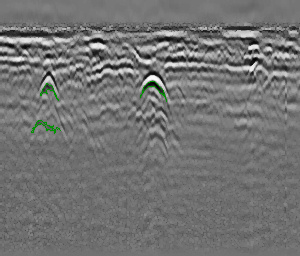

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow # 코랩 전용 이미지 출력 함수 임포트

def analyze_gpr_tda_black_v3(image_path, num_seeds=300, start_threshold=10, step=2, max_area=800,min_area=20):
    # 1. 이미지 로드 및 전처리
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return print("이미지를 찾을 수 없습니다.")

    rows, cols = img.shape
    total_pixel_area = rows * cols

    # [설정] 비율 기반 임계값
    MAX_AREA_RATIO = 0.08
    MIN_WIDTH_RATIO = 0.0
    MIN_DRAW_AREA = 80 # 최종 출력 시 최소 픽셀 수

    # 2. 초기 High-level Seed 생성 (가장 밝은 영역 7~10개 추출)
    # _: 적용된 임계값
    # mask: 0과 255로 이루어진 2D 이진 행렬
    _, initial_mask = cv2.threshold(img, start_threshold, 255, cv2.THRESH_BINARY_INV)

    # input: initial_mask: 특정 임계값 t에서의 이진 행렬
    # return:
    #     - num_labels:(정수) 배경을 포함한 총 연결 성분의 개수
    #     - labels:(2D 행렬) 각 픽셀이 어떤 객체에 속하는지 번호가 매겨진 맵
    #     - stats: (2D 배열) 각 객체의 바운딩 박스 및 면적
    #     - centroids: (2D배열) 각 객체의 무게중심 좌표
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(initial_mask)

    # 면적 순으로 정렬하여 상위 n개만 넘버링 (배경 제외)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(initial_mask)
    sorted_idx = np.argsort(stats[1:, cv2.CC_STAT_AREA])[::-1][:num_seeds]

    seeds = {}

    # current_labels는 추적 중인 객체의 ID를 기록하는 맵입니다.
    current_labels_map = np.zeros_like(labels, dtype=np.int32)

    for i, idx in enumerate(sorted_idx):
        s_id = i + 1
        label_idx = idx + 1
        current_labels_map[labels == label_idx] = s_id

        # 최적화 핵심: 씨앗의 위치를 찾기 위해 np.where를 쓰는 대신 무게중심 좌표를 저장
        cy, cx = int(centroids[label_idx][1]), int(centroids[label_idx][0])

        seeds[s_id] = {
            'label': s_id,
            'anchor_pt': (cy, cx), # 추적용 고정 좌표
            'last_area': stats[label_idx, cv2.CC_STAT_AREA],
            'is_valid': True,
            'is_frozen': False,
            'final_mask': (labels == label_idx).astype(np.uint8) * 255,
            'initial': True
        }

    # 3. Filtration 진행 (임계값을 낮추며 확장)
    for t in range(start_threshold + step, 120, step):
        _, current_mask = cv2.threshold(img, t, 255, cv2.THRESH_BINARY_INV)

        # temp_labels, _, temp_stats, _ = cv2.connectedComponentsWithStats(current_mask)
        # 5개의 인자를 정확히 받아옵니다 (retval, labels, stats, centroids)
        num_objects, labels_map, temp_stats, temp_centroids = cv2.connectedComponentsWithStats(current_mask)


        # ----------------------------------------------------
        # [A] 기존 씨앗들 확장 및 검증
        # ----------------------------------------------------
        for s_id in list(seeds.keys()):
            info = seeds[s_id]
            if not info['is_valid'] or info['is_frozen']: continue

            # 앵커 포인트를 이용해 현재 임계값 맵에서 어떤 객체에 속하는지 즉시 확인
            cy, cx = info['anchor_pt']
            new_label = labels_map[cy, cx]

            if new_label == 0:
                continue

            # 면적 확인
            new_area = temp_stats[new_label, cv2.CC_STAT_AREA]
            if (new_area / total_pixel_area) > MAX_AREA_RATIO:
                info['is_valid'] = False
                info['final_mask'] = None
                continue

            new_width = temp_stats[new_label, cv2.CC_STAT_WIDTH]
            current_width_ratio = new_width / cols

            # 기하학적 분석
            is_hyperbola = False
            passed_geometric_test = False

            if current_width_ratio < MIN_WIDTH_RATIO:
                is_hyperbola = True # 너무 작으면 일단 유지
            else:
                # Bounding Box 내에서만 좌표 추출 (속도 최적화)
                x_s, y_st, w_s, h_s = temp_stats[new_label, :4]
                roi_labels = labels_map[y_st:y_st+h_s, x_s:x_s+w_s]
                pts_y, pts_x = np.where(roi_labels == new_label)
                pts_y += y_st
                pts_x += x_s

                min_x_idx, max_x_idx = np.argmin(pts_x), np.argmax(pts_x)
                lx, ly = pts_x[min_x_idx], pts_y[min_x_idx]
                rx, ry = pts_x[max_x_idx], pts_y[max_x_idx]

                obj_cx = x_s + w_s / 2
                center_margin = max(0, int(new_width * 0.18))
                center_mask = (pts_x >= obj_cx - center_margin) & (pts_x <= obj_cx + center_margin)

                if np.any(center_mask):
                    c_pts_y = pts_y[center_mask]
                    c_pts_x = pts_x[center_mask]
                    apex_idx = np.argmin(c_pts_y)
                    apex_x, apex_y = c_pts_x[apex_idx], c_pts_y[apex_idx]
                    c_bottom_y = np.max(c_pts_y)

                    cond1 = (apex_y <= ly) and (apex_y <= ry)
                    cond2 = (c_bottom_y <= ly) and (c_bottom_y <= ry)

                    dx_r, dy_r = rx - apex_x, ry - apex_y
                    dx_l, dy_l = lx - apex_x, ly - apex_y

                    slope_r = abs(dy_r / dx_r) if dx_r != 0 else 9999.0
                    slope_l = -abs(dy_l / dx_l) if dx_l != 0 else -9999.0

                    if cond1 and cond2 and (0.3 <= slope_r <= 6.2) and (-6.2 <= slope_l <= -0.3):
                        is_hyperbola = True
                        passed_geometric_test = True

            if is_hyperbola:
                info['last_area'] = new_area
                # 다음 단계 추적을 위해 앵커 포인트를 현재 객체의 중심으로 업데이트
                info['anchor_pt'] = (int(temp_centroids[new_label][1]), int(temp_centroids[new_label][0]))
                # 검증 성공 시 마스크 업데이트
                info['final_mask'] = (labels_map == new_label).astype(np.uint8) * 255
                if passed_geometric_test:
                    info["initial"] = False
            else:
                # 조건 탈락 시 '동결'. final_mask는 업데이트되지 않아 이전 상태가 유지됨
                info['is_frozen'] = True
                if info["initial"]:
                    info['is_valid'] = False
                    info['final_mask'] = None

        # ----------------------------------------------------
        # [B] 새로운 씨앗(New Birth) 탐색 및 등록
        # ----------------------------------------------------
        next_id = max(seeds.keys()) + 1 if seeds else 1
        # 현재 labels_map의 객체들 중 기존 씨앗의 앵커 포인트가 없는 곳을 찾음
        for k in range(1, num_objects):
            # 최적화: 새 레이블의 무게중심에 기존 ID가 없으면 새로운 탄생으로 간주
            new_cy, new_cx = int(temp_centroids[k][1]), int(temp_centroids[k][0])
            if current_labels_map[new_cy, new_cx] == 0:
                area_k = temp_stats[k, cv2.CC_STAT_AREA]
                if (area_k / total_pixel_area) <= MAX_AREA_RATIO:
                    seeds[next_id] = {
                        'label': next_id,
                        'anchor_pt': (new_cy, new_cx),
                        'last_area': area_k,
                        'is_valid': True,
                        'is_frozen': False,
                        'final_mask': (labels_map == k).astype(np.uint8) * 255,
                        'initial': True
                    }
                    # 추적 맵에 기록 (겹침 방지)
                    current_labels_map[labels_map == k] = next_id
                    next_id += 1



    # 4. 결과 시각화
    result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    for s_id, info in seeds.items():
        if info['is_valid'] and not info['initial'] and info['final_mask'] is not None:
            if info['last_area'] >= MIN_DRAW_AREA:
                contours, _ = cv2.findContours(info['final_mask'], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                cv2.drawContours(result_img, contours, -1, (0, 150, 0), 1)

    return result_img


# 실행
# output = analyze_gpr_tda_black('/content/drive/MyDrive/TDA/dataset/images/train_signal/pipe_yz_MALA_000049.jpg')
#plt.figure(figsize=(10, 8))
#plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
#plt.title("GPR TDA: Independent Simplex Tracking")
#plt.axis('off')

image_path = '/content/drive/MyDrive/TDA/dataset/images/train_signal_v2/pipe_yz_MALA_000049.jpg'
output = analyze_gpr_tda_black_v3(image_path)
cv2_imshow(output)

## V4: 통합버전

탐지 완료 - 총 시드: 93


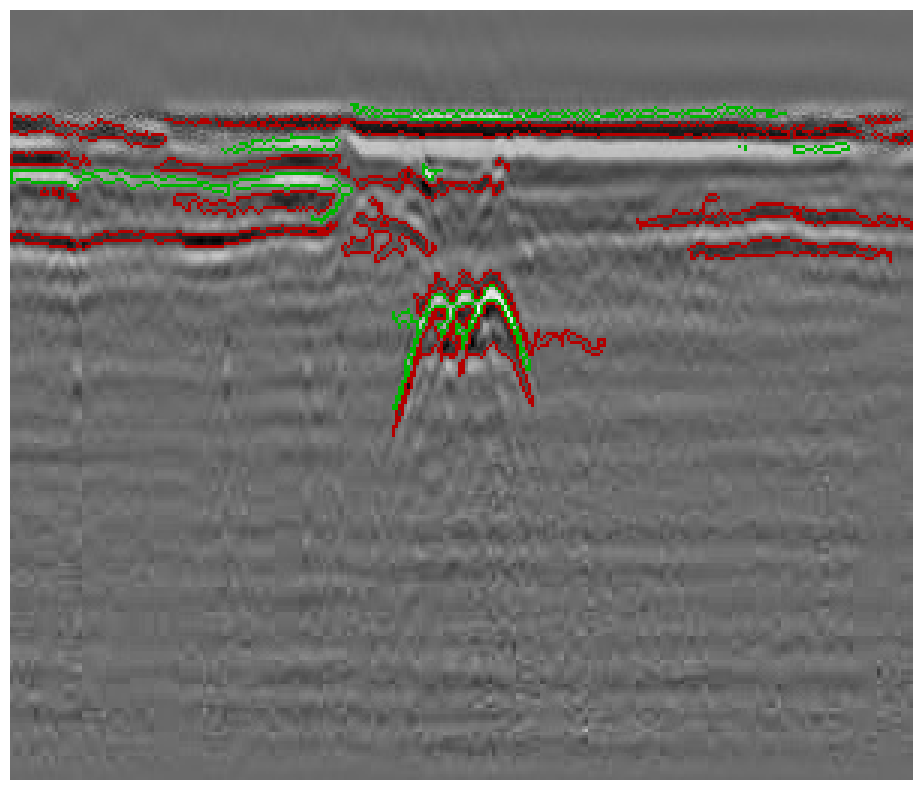

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

def analyze_gpr_tda_fixed(image_path, start_high=230, start_low=10, max_area=400, min_area=20, explosion_ratio=3):
    # 1. 이미지 로드
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return print("이미지를 찾을 수 없습니다.")
    # img_blur = cv2.GaussianBlur(img, (5, 5), 0)

    # 결과용 이미지와 전역 라벨 맵 (모든 모드가 공유)
    result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    # **중요: current_labels를 루프 밖에서 단 한 번만 생성합니다.**
    current_labels = np.zeros(img.shape, dtype=np.int32)

    all_seeds = {}
    global_seed_count = 1

    # [탐지 모드 정의] - 이전 코드들의 조건을 그대로 유지
    modes = [
        {'name': 'Bright', 'start': start_high, 'step': -2, 'thresh_type': cv2.THRESH_BINARY, 'stop': 50}, # 100까지 하강
        {'name': 'Dark', 'start': start_low, 'step': 2, 'thresh_type': cv2.THRESH_BINARY_INV, 'stop': 170}  # 150까지 상승
    ]

    for mode in modes:
        # A. 초기 Seed 생성
        _, initial_mask = cv2.threshold(img, mode['start'], 255, mode['thresh_type'])
        num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(initial_mask)

        mode_seeds = {}
        for idx in range(1, num_labels):
            s_id = global_seed_count
            mode_seeds[s_id] = {
                'label': s_id, 'last_area': stats[idx, cv2.CC_STAT_AREA],
                'is_frozen': False, 'final_mask': None, 'type': mode['name']
            }
            # 전역 라벨 맵에 기록
            current_labels[labels == idx] = s_id
            global_seed_count += 1

        # B. Filtration 과정
        target_range = range(mode['start'] + mode['step'], mode['stop'], mode['step'])

        for t in target_range:
            _, current_mask = cv2.threshold(img, t, 255, mode['thresh_type'])
            _, labels_map, temp_stats, _ = cv2.connectedComponentsWithStats(current_mask)

            for s_id, info in mode_seeds.items():
                if info['is_frozen']: continue

                # 현재 씨앗 위치 확인
                y, x = np.where(current_labels == s_id)
                if len(y) == 0: continue

                target_label = labels_map[int(y[0]), int(x[0])]
                if target_label == 0: continue

                new_area = temp_stats[target_label, cv2.CC_STAT_AREA]

                # Dead 조건 (사용자님 기존 조건 적용)
                if new_area < min_area:
                    current_labels[labels_map == target_label] = s_id
                    info['last_area'] = new_area
                elif (new_area > info['last_area'] * explosion_ratio) or (new_area > max_area):
                    info['is_frozen'] = True
                    info['final_mask'] = (current_labels == s_id).astype(np.uint8) * 255
                else:
                    current_labels[labels_map == target_label] = s_id
                    info['last_area'] = new_area

        all_seeds.update(mode_seeds)

    # 3. 통합 시각화
    for s_id, info in all_seeds.items():
        # 박제된 마스크가 있으면 쓰고, 없으면 현재 맵에서 추출
        if info['final_mask'] is not None:
            mask = info['final_mask']
        else:
            mask = (current_labels == s_id).astype(np.uint8) * 255

        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        color = (0, 180, 0) if info['type'] == 'Bright' else (0, 0, 180)
        cv2.drawContours(result_img, contours, -1, color, 1)

    print(f"탐지 완료 - 총 시드: {len(all_seeds)}")
    return result_img

# 실행
image_path = '/content/drive/MyDrive/TDA/dataset/images/train_signal/pipe_yz_MALA_000038.jpg'
output = analyze_gpr_tda_fixed(image_path, start_high=200, start_low=50) # 좀 더 넉넉한 임계값으로 테스트

plt.figure(figsize=(12, 10))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

## V4-1

통합과 쌍곡선에서 조건을 조금씩 바꾸기
가장 최근 버전 5/8

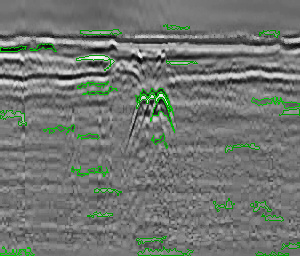

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

def analyze_gpr_tda_both(image_path, num_seeds=300, step=2):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        print("이미지를 찾을 수 없습니다.")
        return None

    def run_filtration(mode):
        rows, cols = img.shape
        total_pixel_area = rows * cols

        MAX_AREA_RATIO = 0.08
        MIN_WIDTH_RATIO = 0.0
        MIN_DRAW_AREA = 80

        if mode == "dark":
            start_threshold = 10
            end_threshold = 120
            threshold_type = cv2.THRESH_BINARY_INV
            thresholds = range(start_threshold + step, end_threshold, step)

        elif mode == "bright":
            start_threshold = 240
            end_threshold = 80
            threshold_type = cv2.THRESH_BINARY
            thresholds = range(start_threshold - step, end_threshold, -step)

        else:
            raise ValueError("mode는 'dark' 또는 'bright'만 가능합니다.")

        _, initial_mask = cv2.threshold(
            img,
            start_threshold,
            255,
            threshold_type
        )

        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(initial_mask)

        sorted_idx = np.argsort(stats[1:, cv2.CC_STAT_AREA])[::-1][:num_seeds]

        seeds = {}
        current_labels_map = np.zeros_like(labels, dtype=np.int32)

        for i, idx in enumerate(sorted_idx):
            s_id = i + 1
            label_idx = idx + 1

            current_labels_map[labels == label_idx] = s_id
            cy, cx = int(centroids[label_idx][1]), int(centroids[label_idx][0])

            seeds[s_id] = {
                "label": s_id,
                "anchor_pt": (cy, cx),
                "last_area": stats[label_idx, cv2.CC_STAT_AREA],
                "is_valid": True,
                "is_frozen": False,
                "final_mask": (labels == label_idx).astype(np.uint8) * 255,
                "initial": True
            }

        for t in thresholds:
            _, current_mask = cv2.threshold(
                img,
                t,
                255,
                threshold_type
            )

            num_objects, labels_map, temp_stats, temp_centroids = cv2.connectedComponentsWithStats(current_mask)

            for s_id in list(seeds.keys()):
                info = seeds[s_id]

                if not info["is_valid"] or info["is_frozen"]:
                    continue

                cy, cx = info["anchor_pt"]
                new_label = labels_map[cy, cx]

                if new_label == 0:
                    continue

                new_area = temp_stats[new_label, cv2.CC_STAT_AREA]

                if (new_area / total_pixel_area) > MAX_AREA_RATIO:
                    info["is_valid"] = False
                    info["final_mask"] = None
                    continue

                new_width = temp_stats[new_label, cv2.CC_STAT_WIDTH]
                current_width_ratio = new_width / cols

                is_hyperbola = False
                passed_geometric_test = False

                if current_width_ratio < MIN_WIDTH_RATIO:
                    is_hyperbola = True

                else:
                    x_s, y_st, w_s, h_s = temp_stats[new_label, :4]

                    roi_labels = labels_map[y_st:y_st+h_s, x_s:x_s+w_s]
                    pts_y, pts_x = np.where(roi_labels == new_label)

                    pts_y += y_st
                    pts_x += x_s

                    obj_cx = x_s + w_s / 2
                    center_margin = max(1, int(new_width * 0.18))

                    center_mask = (
                        (pts_x >= obj_cx - center_margin) &
                        (pts_x <= obj_cx + center_margin)
                    )

                    if np.any(center_mask):
                        c_pts_y = pts_y[center_mask]
                        c_pts_x = pts_x[center_mask]

                        apex_idx = np.argmin(c_pts_y)
                        apex_x, apex_y = c_pts_x[apex_idx], c_pts_y[apex_idx]

                        c_bottom_y = np.max(c_pts_y)

                        below_mask = pts_y > apex_y + int(h_s * 0.15)
                        side_gap = max(2, int(new_width * 0.15))

                        left_mask = below_mask & (pts_x < apex_x - side_gap)
                        right_mask = below_mask & (pts_x > apex_x + side_gap)

                        if np.any(left_mask) and np.any(right_mask):
                            left_y = np.percentile(pts_y[left_mask], 85)
                            right_y = np.percentile(pts_y[right_mask], 85)

                            left_candidates = np.where(left_mask & (pts_y >= left_y))[0]
                            right_candidates = np.where(right_mask & (pts_y >= right_y))[0]

                            lx = int(np.median(pts_x[left_candidates]))
                            ly = int(np.median(pts_y[left_candidates]))

                            rx = int(np.median(pts_x[right_candidates]))
                            ry = int(np.median(pts_y[right_candidates]))

                            cond1 = (apex_y <= ly) and (apex_y <= ry)
                            cond2 = (c_bottom_y <= ly) and (c_bottom_y <= ry)

                            dx_r, dy_r = rx - apex_x, ry - apex_y
                            dx_l, dy_l = lx - apex_x, ly - apex_y

                            slope_r = abs(dy_r / dx_r) if dx_r != 0 else 9999.0
                            slope_l = -abs(dy_l / dx_l) if dx_l != 0 else -9999.0

                            if cond1 and cond2 and (0.3 <= slope_r <= 6.2) and (-6.2 <= slope_l <= -0.3):
                                is_hyperbola = True
                                passed_geometric_test = True

                if is_hyperbola:
                    info["last_area"] = new_area
                    info["anchor_pt"] = (
                        int(temp_centroids[new_label][1]),
                        int(temp_centroids[new_label][0])
                    )
                    info["final_mask"] = (labels_map == new_label).astype(np.uint8) * 255

                    if passed_geometric_test:
                        info["initial"] = False

                else:
                    info["is_frozen"] = True

                    if info["initial"]:
                        info["is_valid"] = False
                        info["final_mask"] = None

            next_id = max(seeds.keys()) + 1 if seeds else 1

            for k in range(1, num_objects):
                new_cy, new_cx = int(temp_centroids[k][1]), int(temp_centroids[k][0])

                if current_labels_map[new_cy, new_cx] == 0:
                    area_k = temp_stats[k, cv2.CC_STAT_AREA]

                    if (area_k / total_pixel_area) <= MAX_AREA_RATIO:
                        seeds[next_id] = {
                            "label": next_id,
                            "anchor_pt": (new_cy, new_cx),
                            "last_area": area_k,
                            "is_valid": True,
                            "is_frozen": False,
                            "final_mask": (labels_map == k).astype(np.uint8) * 255,
                            "initial": True
                        }

                        current_labels_map[labels_map == k] = next_id
                        next_id += 1

        final_mask_all = np.zeros_like(img, dtype=np.uint8)

        for s_id, info in seeds.items():
            if info["is_valid"] and not info["initial"] and info["final_mask"] is not None:
                if info["last_area"] >= MIN_DRAW_AREA:
                    final_mask_all = cv2.bitwise_or(final_mask_all, info["final_mask"])

        return final_mask_all

    dark_mask = run_filtration("dark")
    bright_mask = run_filtration("bright")

    result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)

    dark_contours, _ = cv2.findContours(dark_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    bright_contours, _ = cv2.findContours(bright_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # 어두운 영역 기반 결과: 초록색
    cv2.drawContours(result_img, dark_contours, -1, (0, 200, 0), 1)

    # 밝은 영역 기반 결과: 빨간색
    cv2.drawContours(result_img, bright_contours, -1, (0, 160, 0), 1)

    return result_img

image_path = "/content/drive/MyDrive/TDA/dataset/images/train_signal_v2/pipe_yz_MALA_000038.jpg"

output = analyze_gpr_tda_both(image_path)
cv2_imshow(output)

## Persistent Homoloty 결과 저장

In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

input_dir_tr = '/content/drive/MyDrive/TDA/dataset/images/train_signal_v2'# 코드 방지용
input_dir_val = '/content/drive/MyDrive/TDA/dataset/images/val_signal_v2'
output_dir_val = '/content/drive/MyDrive/TDA/dataset/images/val_signal_v2_PH_v2_both'
output_dir_tr = '/content/drive/MyDrive/TDA/dataset/images/train_signal_v2_PH_v2_both'

# 2. 폴더 매핑 (입력 폴더와 그에 대응하는 출력 폴더 쌍)
dirs_to_process = [
    (input_dir_tr, output_dir_tr),
    (input_dir_val, output_dir_val)
]

# 결과 디렉토리가 없으면 생성
if not os.path.exists(output_dir_tr):
    os.makedirs(output_dir_tr)
    print(f"디렉토리 생성됨: {output_dir_tr}")
if not os.path.exists(output_dir_val):
    os.makedirs(output_dir_val)
    print(f"디렉토리 생성됨: {output_dir_val}")



for in_dir, out_dir in dirs_to_process:
  count = 0
  # 이미지 파일 목록 가져오기
  files = [f for f in os.listdir(in_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
  print(f"\n[{in_dir}]에서 [{out_dir}]로 변환 시작 (총 {len(files)}개)")



  for count, filename in enumerate(tqdm(files)):
    # 1. 이미지 읽기
    img_path = os.path.join(in_dir, filename)
    img = cv2.imread(img_path)

    if img is None:
        continue

    # 2. 신호 감쇄 적용
    # attenuation_factor는 데이터의 특성에 맞춰 조절하세요 (0.001 ~ 0.01 사이 권장)
    processed_img = analyze_gpr_tda_both(img_path)

    #if count < 5:
    #    print(f"Sample {count+1}: {filename}")
    #    cv2_imshow(img)
    #    cv2_imshow(processed_img)

    # 3. 동일한 이름으로 저장
    save_path = os.path.join(out_dir, filename)
    cv2.imwrite(save_path, processed_img)

print("\n모든 작업이 완료되었습니다.")

디렉토리 생성됨: /content/drive/MyDrive/TDA/dataset/images/train_signal_v2_PH_v2_both
디렉토리 생성됨: /content/drive/MyDrive/TDA/dataset/images/val_signal_v2_PH_v2_both

[/content/drive/MyDrive/TDA/dataset/images/train_signal_v2]에서 [/content/drive/MyDrive/TDA/dataset/images/train_signal_v2_PH_v2_both]로 변환 시작 (총 2997개)


100%|██████████| 2997/2997 [2:20:56<00:00,  2.82s/it]



[/content/drive/MyDrive/TDA/dataset/images/val_signal_v2]에서 [/content/drive/MyDrive/TDA/dataset/images/val_signal_v2_PH_v2_both]로 변환 시작 (총 4294개)


100%|██████████| 4294/4294 [4:06:52<00:00,  3.45s/it]


모든 작업이 완료되었습니다.


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

input_dir_tr = '/content/drive/MyDrive/TDA/dataset/images/train_signal_v2'# 코드 방지용
input_dir_val = '/content/drive/MyDrive/TDA/dataset/images/val_signal_v2'
output_dir_val = '/content/drive/MyDrive/TDA/dataset/images/val_signal_v2_PH_v1_1'
output_dir_tr = '/content/drive/MyDrive/TDA/dataset/images/train_signal_v2_PH_v1_1'

# 2. 폴더 매핑 (입력 폴더와 그에 대응하는 출력 폴더 쌍)
dirs_to_process = [
    (input_dir_tr, output_dir_tr),
    (input_dir_val, output_dir_val)
]

# 결과 디렉토리가 없으면 생성
if not os.path.exists(output_dir_tr):
    os.makedirs(output_dir_tr)
    print(f"디렉토리 생성됨: {output_dir_tr}")
if not os.path.exists(output_dir_val):
    os.makedirs(output_dir_val)
    print(f"디렉토리 생성됨: {output_dir_val}")



for in_dir, out_dir in dirs_to_process:
  count = 0
  # 이미지 파일 목록 가져오기
  files = [f for f in os.listdir(in_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
  print(f"\n[{in_dir}]에서 [{out_dir}]로 변환 시작 (총 {len(files)}개)")



  for count, filename in enumerate(tqdm(files)):
    # 1. 이미지 읽기
    img_path = os.path.join(in_dir, filename)
    img = cv2.imread(img_path)

    if img is None:
        continue

    # 2. 신호 감쇄 적용
    # attenuation_factor는 데이터의 특성에 맞춰 조절하세요 (0.001 ~ 0.01 사이 권장)
    processed_img = analyze_gpr_tda_v3(img_path)

    #if count < 5:
    #    print(f"Sample {count+1}: {filename}")
    #    cv2_imshow(img)
    #    cv2_imshow(processed_img)

    # 3. 동일한 이름으로 저장
    save_path = os.path.join(out_dir, filename)
    cv2.imwrite(save_path, processed_img)

print("\n모든 작업이 완료되었습니다.")

디렉토리 생성됨: /content/drive/MyDrive/TDA/dataset/images/train_signal_v2_PH_v1_1
디렉토리 생성됨: /content/drive/MyDrive/TDA/dataset/images/val_signal_v2_PH_v1_1

[/content/drive/MyDrive/TDA/dataset/images/train_signal_v2]에서 [/content/drive/MyDrive/TDA/dataset/images/train_signal_v2_PH_v1_1]로 변환 시작 (총 2997개)


100%|██████████| 2997/2997 [39:17<00:00,  1.27it/s]



[/content/drive/MyDrive/TDA/dataset/images/val_signal_v2]에서 [/content/drive/MyDrive/TDA/dataset/images/val_signal_v2_PH_v1_1]로 변환 시작 (총 4294개)


100%|██████████| 4294/4294 [56:57<00:00,  1.26it/s]


모든 작업이 완료되었습니다.


In [ ]:
import os
import cv2
import numpy as np
from tqdm import tqdm

input_dir_tr = '/content/drive/MyDrive/TDA/dataset/images/train_signal_v2'# 코드 방지용
input_dir_val = '/content/drive/MyDrive/TDA/dataset/images/val_signal_v2'
output_dir_val = '/content/drive/MyDrive/TDA/dataset/images/val_signal_v2_PH_v2_bl'
output_dir_tr = '/content/drive/MyDrive/TDA/dataset/images/train_signal_v2_PH_v2_bl'

# 2. 폴더 매핑 (입력 폴더와 그에 대응하는 출력 폴더 쌍)
dirs_to_process = [
    (input_dir_tr, output_dir_tr),
    (input_dir_val, output_dir_val)
]

# 결과 디렉토리가 없으면 생성
if not os.path.exists(output_dir_tr):
    os.makedirs(output_dir_tr)
    print(f"디렉토리 생성됨: {output_dir_tr}")
if not os.path.exists(output_dir_val):
    os.makedirs(output_dir_val)
    print(f"디렉토리 생성됨: {output_dir_val}")



for in_dir, out_dir in dirs_to_process:
  count = 0
  # 이미지 파일 목록 가져오기
  files = [f for f in os.listdir(in_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
  print(f"\n[{in_dir}]에서 [{out_dir}]로 변환 시작 (총 {len(files)}개)")



  for count, filename in enumerate(tqdm(files)):
    # 1. 이미지 읽기
    img_path = os.path.join(in_dir, filename)
    img = cv2.imread(img_path)

    if img is None:
        continue

    # 2. 신호 감쇄 적용
    # attenuation_factor는 데이터의 특성에 맞춰 조절하세요 (0.001 ~ 0.01 사이 권장)
    processed_img = analyze_gpr_tda_black_v3(img_path)

    #if count < 5:
    #    print(f"Sample {count+1}: {filename}")
    #    cv2_imshow(img)
    #    cv2_imshow(processed_img)

    # 3. 동일한 이름으로 저장
    save_path = os.path.join(out_dir, filename)
    cv2.imwrite(save_path, processed_img)

print("\n모든 작업이 완료되었습니다.")


[/content/drive/MyDrive/TDA/dataset/images/train_signal_v2]에서 [/content/drive/MyDrive/TDA/dataset/images/train_signal_v2_PH_v2_bl]로 변환 시작 (총 2997개)


100%|██████████| 2997/2997 [1:59:15<00:00,  2.39s/it]



[/content/drive/MyDrive/TDA/dataset/images/val_signal_v2]에서 [/content/drive/MyDrive/TDA/dataset/images/val_signal_v2_PH_v2_bl]로 변환 시작 (총 4294개)


100%|██████████| 4294/4294 [2:50:13<00:00,  2.38s/it]


모든 작업이 완료되었습니다.


## v2

사용자님의 수정된 의도는 TDA의 여과(Filtration) 과정에서 데이터가 가진 본래의 위상적 특징을 훨씬 더 역동적으로 포착하려는 전략으로 이해됩니다. 처음에 정해둔 개수만 추적하는 것이 아니라, 임계값이 낮아지면서 **새롭게 출현(Birth)**하는 모든 유의미한 덩어리를 새로운 씨앗(Seed)으로 인정하고 개별적으로 관리하겠다는 의미시군요.

GPR 데이터에서 이는 매우 중요한데, 강한 반사파뿐만 아니라 깊은 곳이나 매질 차이로 인해 뒤늦게 나타나는 약한 쌍곡선(Hyperbola) 신호들도 놓치지 않고 각각의 단순체(Simplex) 객체로 등재할 수 있기 때문입니다.

이를 반영하여 코드를 더욱 유연하게 개선해 보았습니다.

개선된 GPR TDA 코드: 동적 씨앗 생성 및 추적

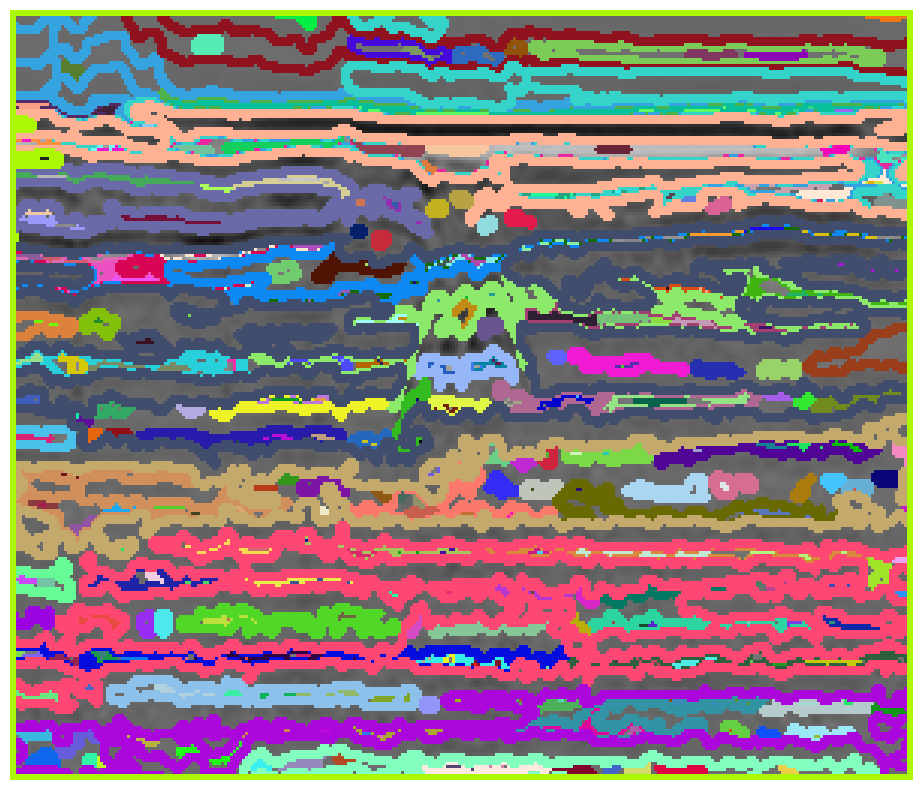

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def dynamic_gpr_tda(image_path, start_threshold=250, end_threshold=50, step=3):
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return
    img = cv2.GaussianBlur(img, (5, 5), 0) #  [cite: 11, 25] # 저수준 필터링으로 노이즈 제거 [cite: 25]

    # 객체 관리를 위한 딕셔너리 (ID: 정보)
    active_seeds = {}
    next_id = 1
    final_results = []

    # High-level set filtration 수행 [cite: 14, 71, 72]
    for t in range(start_threshold, end_threshold, -step):
        _, mask = cv2.threshold(img, t, 255, cv2.THRESH_BINARY)
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)

        current_frame_used_labels = set()

        # 1. 기존에 추적 중인 씨앗들 업데이트
        for s_id, info in list(active_seeds.items()):
            if info['frozen']: continue

            # 이전 위치(centroid)를 기준으로 현재 임계값에서의 레이블 찾기
            cx, cy = info['last_centroid']
            target_label = labels[int(cy), int(cx)]

            if target_label > 0:
                new_area = stats[target_label, cv2.CC_STAT_AREA]
                # 급격한 변화(Explosion) 감지 시 박제 [cite: 19, 93]
                if new_area > info['last_area'] * 2.0:
                    info['frozen'] = True
                    final_results.append(info)
                    del active_seeds[s_id]
                else:
                    info['last_area'] = new_area
                    info['last_centroid'] = centroids[target_label]
                    info['mask'] = (labels == target_label).astype(np.uint8) * 255
                    current_frame_used_labels.add(target_label)
            else:
                # 신호가 사라진 경우 (GPR 특성상 드물지만 대비)
                info['frozen'] = True
                final_results.append(info)
                del active_seeds[s_id]

        # 2. 새로운 씨앗 발견 (Birth) [cite: 93, 95]
        for l_idx in range(1, num_labels):
            if l_idx not in current_frame_used_labels:
                # 일정 크기 이상의 새로운 영역이 나타나면 신규 씨앗으로 등록
                if stats[l_idx, cv2.CC_STAT_AREA] > 10:
                    active_seeds[next_id] = {
                        'id': next_id,
                        'last_area': stats[l_idx, cv2.CC_STAT_AREA],
                        'last_centroid': centroids[l_idx],
                        'mask': (labels == l_idx).astype(np.uint8) * 255,
                        'frozen': False,
                        'birth_t': t
                    }
                    next_id += 1

    # 결과 시각화
    display_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    for res in final_results + list(active_seeds.values()):
        contours, _ = cv2.findContours(res['mask'], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        color = list(np.random.random(size=3) * 256)
        cv2.drawContours(display_img, contours, -1, color, 2)

    return display_img

# 실행 및 출력
output = dynamic_gpr_tda('/content/drive/MyDrive/TDA/dataset/images/train_signal/pipe_yz_MALA_000038.jpg')
plt.figure(figsize=(12, 10))
plt.imshow(output)
plt.axis('off')
plt.show()

연구용

임계값(Threshold)이 변함에 따라 새로운 씨앗이 **탄생(Birth)**하고, 기존 객체가 확장되다가 다른 요소와 부딪혀 **박제(Frozen)**되는 과정을 시각적으로 하나하나 확인할 수 있는 두 번째 버전의 코드를 작성해 드립니다.

이 코드는 모든 임계값 단계에서의 스냅샷을 저장하거나 화면에 출력하여, GPR 데이터에서 단순체(Simplex)가 어떻게 형성되는지 추적할 수 있게 설계되었습니다.

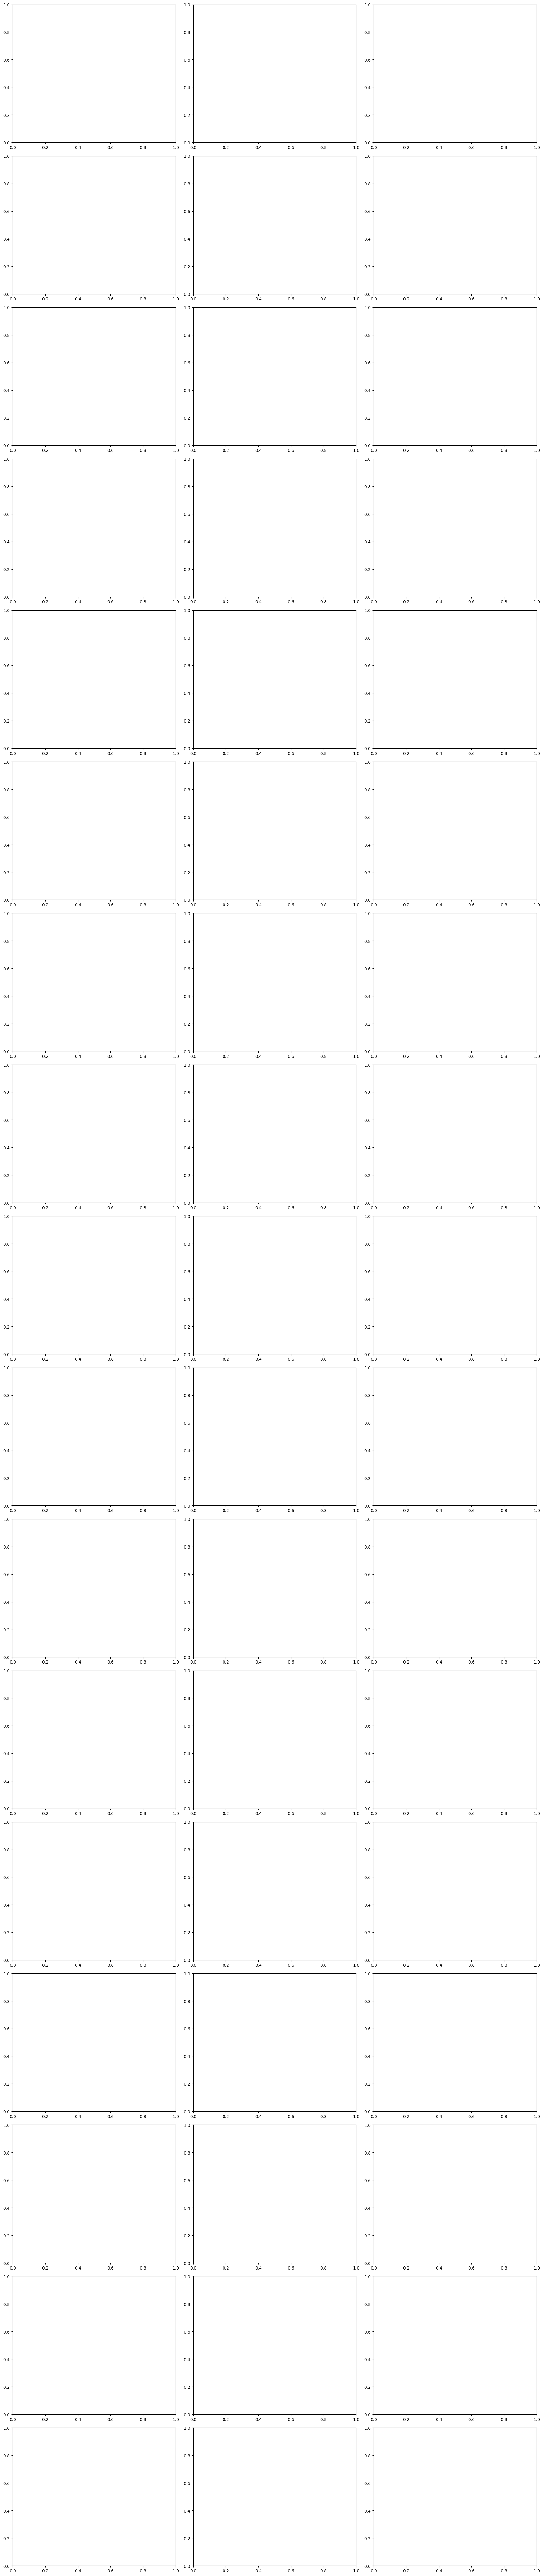

[{'id': 2,
  'birth_t': 186,
  'last_area': np.int32(21),
  'last_centroid': array([149.23809524,  45.47619048]),
  'mask': array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
  'freeze_t': 186},
 {'id': 1,
  'birth_t': 186,
  'last_area': np.int32(28),
  'last_centroid': array([121.57142857,  45.32142857]),
  'mask': array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0]], dtype=uint8),
  'freeze_t': 182},
 {'id': 5,
  'birth_t': 182,
  'last_area': np.int32(37),
  'last_centroid': array([148.45945946,  45.54054054]),
  'mask': array([[0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         [0, 0, 0, ..., 0, 0, 0],
         ...,
         [0,

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

def analyze_gpr_step_by_step(image_path, start_t=250, end_t=50, step=5, explosion_ratio=1.8):
    # 1. 이미지 로드 및 기본 필터링 [cite: 11, 25]
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return
    img_blur = cv2.GaussianBlur(img, (5, 5), 0)

    active_seeds = {} # 현재 추적 중인 객체
    final_polygons = [] # 박제된 최종 객체들
    next_id = 1

    # 시각화 설정
    rows = ((start_t - end_t) // (step * 3)) + 1
    fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 5))
    axes = axes.flatten()
    ax_idx = 0

    # 2. High-level set filtration 진행 (밝은 곳 -> 어두운 곳) [cite: 72, 92]
    for t in range(start_t, end_t, -step):
        _, mask = cv2.threshold(img_blur, t, 255, cv2.THRESH_BINARY)
        num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(mask)

        current_frame_occupied = np.zeros_like(labels)
        matched_labels = set()

        # [기존 객체 업데이트 및 폭발 감지]
        for s_id, info in list(active_seeds.items()):
            cx, cy = info['last_centroid']
            target_l = labels[int(cy), int(cx)]

            if target_l > 0:
                new_area = stats[target_l, cv2.CC_STAT_AREA]

                # 면적 변화율 계산 (이전 단계 대비 갑격한 팽창 확인)
                if new_area > info['last_area'] * explosion_ratio:
                    # 급격히 커지기 직전 상태를 최종 결과에 저장 (박제)
                    info['freeze_t'] = t + step
                    final_polygons.append(info)
                    del active_seeds[s_id]
                else:
                    # 안정적인 성장이면 정보 업데이트
                    info['last_area'] = new_area
                    info['last_centroid'] = centroids[target_l]
                    info['mask'] = (labels == target_l).astype(np.uint8) * 255
                    matched_labels.add(target_l)
                    current_frame_occupied[labels == target_l] = s_id

        # [새로운 객체 탄생 (Birth) 감지] [cite: 93]
        for l_idx in range(1, num_labels):
            if l_idx not in matched_labels and stats[l_idx, cv2.CC_STAT_AREA] > 15:
                active_seeds[next_id] = {
                    'id': next_id,
                    'birth_t': t,
                    'last_area': stats[l_idx, cv2.CC_STAT_AREA],
                    'last_centroid': centroids[l_idx],
                    'mask': (labels == l_idx).astype(np.uint8) * 255,
                    'freeze_t': None
                }
                next_id += 1

        # [특정 간격마다 현재 상태 출력]
        if ax_idx < len(axes) and (t % (step * 3) == 0):
            display = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
            # 현재 추적 중인 모든 객체 그리기
            for s_id, info in active_seeds.items():
                contours, _ = cv2.findContours(info['mask'], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                cv2.drawContours(display, contours, -1, (0, 255, 0), 2) # 추적 중: 초록색
                cv2.putText(display, f"ID:{s_id}", (int(info['last_centroid'][0]), int(info['last_centroid'][1])),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.4, (0, 255, 0), 1)

            # 이미 박제된 객체들 그리기
            for res in final_polygons:
                contours, _ = cv2.findContours(res['mask'], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                cv2.drawContours(display, contours, -1, (0, 0, 255), 2) # 박제됨: 빨간색

            axes[ax_idx].imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
            axes[ax_idx].set_title(f"Threshold: {t} (Active:{len(active_seeds)})")
            axes[ax_idx].axis('off')
            ax_idx += 1

    plt.tight_layout()
    plt.show()
    return final_polygons

# 이미지 경로를 넣어 실행해보세요.
# explosion_ratio를 조절하여 '급격한 변화'의 민감도를 테스트할 수 있습니다.
results = analyze_gpr_step_by_step('/content/drive/MyDrive/TDA/dataset/images/train_signal/pipe_yz_MALA_000038.jpg', step=4, explosion_ratio=1.7)
results

## V3

### 이 코드에서는 con3, con4를 or를 적용하여 불규칙이 있거나 만족하지 않아도 가능하도록 했다.
### 가장 우, 오른이 아닌 우, 오른쪽에서 속하지만 아래에 있는 걸 가져오기
### 이거는 부분으로 가져올 것인데... 쌍곡선의 가장 높은 y값을 가진 애가 중심으로
### 이후에 y값이 내려가면서 오른쪽으로 가는 걸 선택하

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow # 코랩 전용 이미지 출력 함수 임포트

def analyze_gpr_tda_black_v3(image_path, num_seeds=300, start_threshold=10, step=2, max_area=800,min_area=20):
    # 1. 이미지 로드 및 전처리
    img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return print("이미지를 찾을 수 없습니다.")

    rows, cols = img.shape
    total_pixel_area = rows * cols

    # [설정] 비율 기반 임계값
    MAX_AREA_RATIO = 0.08
    MIN_WIDTH_RATIO = 0.03
    MIN_DRAW_AREA = 80 # 최종 출력 시 최소 픽셀 수

    # 2. 초기 High-level Seed 생성 (가장 밝은 영역 7~10개 추출)
    # _: 적용된 임계값
    # mask: 0과 255로 이루어진 2D 이진 행렬
    _, initial_mask = cv2.threshold(img, start_threshold, 255, cv2.THRESH_BINARY_INV)

    # input: initial_mask: 특정 임계값 t에서의 이진 행렬
    # return:
    #     - num_labels:(정수) 배경을 포함한 총 연결 성분의 개수
    #     - labels:(2D 행렬) 각 픽셀이 어떤 객체에 속하는지 번호가 매겨진 맵
    #     - stats: (2D 배열) 각 객체의 바운딩 박스 및 면적
    #     - centroids: (2D배열) 각 객체의 무게중심 좌표
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(initial_mask)

    # 면적 순으로 정렬하여 상위 n개만 넘버링 (배경 제외)
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(initial_mask)
    sorted_idx = np.argsort(stats[1:, cv2.CC_STAT_AREA])[::-1][:num_seeds]

    seeds = {}

    # current_labels는 추적 중인 객체의 ID를 기록하는 맵입니다.
    current_labels_map = np.zeros_like(labels, dtype=np.int32)

    for i, idx in enumerate(sorted_idx):
        s_id = i + 1
        label_idx = idx + 1
        current_labels_map[labels == label_idx] = s_id

        # 최적화 핵심: 씨앗의 위치를 찾기 위해 np.where를 쓰는 대신 무게중심 좌표를 저장
        cy, cx = int(centroids[label_idx][1]), int(centroids[label_idx][0])

        seeds[s_id] = {
            'label': s_id,
            'anchor_pt': (cy, cx), # 추적용 고정 좌표
            'last_area': stats[label_idx, cv2.CC_STAT_AREA],
            'is_valid': True,
            'is_frozen': False,
            'final_mask': (labels == label_idx).astype(np.uint8) * 255,
            'initial': True
        }

    # 3. Filtration 진행 (임계값을 낮추며 확장)
    for t in range(start_threshold + step, 120, step):
        _, current_mask = cv2.threshold(img, t, 255, cv2.THRESH_BINARY_INV)

        # temp_labels, _, temp_stats, _ = cv2.connectedComponentsWithStats(current_mask)
        # 5개의 인자를 정확히 받아옵니다 (retval, labels, stats, centroids)
        num_objects, labels_map, temp_stats, temp_centroids = cv2.connectedComponentsWithStats(current_mask)


        # ----------------------------------------------------
        # [A] 기존 씨앗들 확장 및 검증
        # ----------------------------------------------------
        for s_id in list(seeds.keys()):
            info = seeds[s_id]
            if not info['is_valid'] or info['is_frozen']: continue

            # 앵커 포인트를 이용해 현재 임계값 맵에서 어떤 객체에 속하는지 즉시 확인
            cy, cx = info['anchor_pt']
            new_label = labels_map[cy, cx]

            if new_label == 0:
                continue

            # 면적 확인
            new_area = temp_stats[new_label, cv2.CC_STAT_AREA]
            if (new_area / total_pixel_area) > MAX_AREA_RATIO:
                info['is_valid'] = False
                info['final_mask'] = None
                continue

            new_width = temp_stats[new_label, cv2.CC_STAT_WIDTH]
            current_width_ratio = new_width / cols

            # 기하학적 분석
            is_hyperbola = False
            passed_geometric_test = False

            if current_width_ratio < MIN_WIDTH_RATIO:
                is_hyperbola = True # 너무 작으면 일단 유지
            else:
                # Bounding Box 내에서만 좌표 추출 (속도 최적화)
                x_s, y_st, w_s, h_s = temp_stats[new_label, :4]
                roi_labels = labels_map[y_st:y_st+h_s, x_s:x_s+w_s]
                pts_y, pts_x = np.where(roi_labels == new_label)
                pts_y += y_st
                pts_x += x_s

                min_x_idx, max_x_idx = np.argmin(pts_x), np.argmax(pts_x)
                lx, ly = pts_x[min_x_idx], pts_y[min_x_idx]
                rx, ry = pts_x[max_x_idx], pts_y[max_x_idx]

                obj_cx = x_s + w_s / 2
                center_margin = max(0, int(new_width * 0.18))
                center_mask = (pts_x >= obj_cx - center_margin) & (pts_x <= obj_cx + center_margin)

                if np.any(center_mask):
                    c_pts_y = pts_y[center_mask]
                    c_pts_x = pts_x[center_mask]
                    apex_idx = np.argmin(c_pts_y)
                    apex_x, apex_y = c_pts_x[apex_idx], c_pts_y[apex_idx]
                    c_bottom_y = np.max(c_pts_y)

                    cond1 = (apex_y <= ly) and (apex_y <= ry)
                    cond2 = (c_bottom_y <= ly) and (c_bottom_y <= ry)

                    dx_r, dy_r = rx - apex_x, ry - apex_y
                    dx_l, dy_l = lx - apex_x, ly - apex_y

                    slope_r = abs(dy_r / dx_r) if dx_r != 0 else 9999.0
                    slope_l = -abs(dy_l / dx_l) if dx_l != 0 else -9999.0

                    if cond1 and cond2 and ((0.3 <= slope_r <= 6.2) or (-6.2 <= slope_l <= -0.3)):
                        is_hyperbola = True
                        passed_geometric_test = True

            if is_hyperbola:
                info['last_area'] = new_area
                # 다음 단계 추적을 위해 앵커 포인트를 현재 객체의 중심으로 업데이트
                info['anchor_pt'] = (int(temp_centroids[new_label][1]), int(temp_centroids[new_label][0]))
                # 검증 성공 시 마스크 업데이트
                info['final_mask'] = (labels_map == new_label).astype(np.uint8) * 255
                if passed_geometric_test:
                    info["initial"] = False
            else:
                # 조건 탈락 시 '동결'. final_mask는 업데이트되지 않아 이전 상태가 유지됨
                info['is_frozen'] = True
                if info["initial"]:
                    info['is_valid'] = False
                    info['final_mask'] = None

        # ----------------------------------------------------
        # [B] 새로운 씨앗(New Birth) 탐색 및 등록
        # ----------------------------------------------------
        next_id = max(seeds.keys()) + 1 if seeds else 1
        # 현재 labels_map의 객체들 중 기존 씨앗의 앵커 포인트가 없는 곳을 찾음
        for k in range(1, num_objects):
            # 최적화: 새 레이블의 무게중심에 기존 ID가 없으면 새로운 탄생으로 간주
            new_cy, new_cx = int(temp_centroids[k][1]), int(temp_centroids[k][0])
            if current_labels_map[new_cy, new_cx] == 0:
                area_k = temp_stats[k, cv2.CC_STAT_AREA]
                if (area_k / total_pixel_area) <= MAX_AREA_RATIO:
                    seeds[next_id] = {
                        'label': next_id,
                        'anchor_pt': (new_cy, new_cx),
                        'last_area': area_k,
                        'is_valid': True,
                        'is_frozen': False,
                        'final_mask': (labels_map == k).astype(np.uint8) * 255,
                        'initial': True
                    }
                    # 추적 맵에 기록 (겹침 방지)
                    current_labels_map[labels_map == k] = next_id
                    next_id += 1



    # 4. 결과 시각화
    result_img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
    for s_id, info in seeds.items():
        if info['is_valid'] and not info['initial'] and info['final_mask'] is not None:
            if info['last_area'] >= MIN_DRAW_AREA:
                contours, _ = cv2.findContours(info['final_mask'], cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
                cv2.drawContours(result_img, contours, -1, (0, 150, 0), 1)

    return result_img


# 실행
# output = analyze_gpr_tda_black('/content/drive/MyDrive/TDA/dataset/images/train_signal/pipe_yz_MALA_000049.jpg')
#plt.figure(figsize=(10, 8))
#plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
#plt.title("GPR TDA: Independent Simplex Tracking")
#plt.axis('off')

image_path = '/content/drive/MyDrive/TDA/dataset/images/train_signal_v2/pipe_yz_MALA_000049.jpg'
output = analyze_gpr_tda_black_v3(image_path)
cv2_imshow(output)

# 이 코드에서는 con3, con4를 or를 적용하여 불규칙이 있거나 만족하지 않아도 가능하도록 했다.
# 가장 우, 오른이 아닌 우, 오른쪽에서 속하지만 아래에 있는 걸 가져오기